In [9]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, str(Path("..").resolve()))

ANALYSIS_DIR = Path("../data/analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("../data/output")

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {
   "full": "#456990", "no_formulation": "#49BEAA", "zero_shot": "#EF767A"
}
EVAL_MODELS = {
    "gpt-5.4", "gpt-5.4-mini", "gpt-4o-mini",
    "claude-sonnet-4-6", "claude-haiku-4-5",
    "gemini-2.5-flash", "gemini-2.5-pro",
    "deepseek-chat", "deepseek-reasoner",
    "qwen2.5-32b", "qwen3.6-35b",
}
print("Ready")

Ready


## 1. Load vignettes (cached)

In [10]:
DF_CACHE = ANALYSIS_DIR / "all_vignettes.parquet"

if DF_CACHE.exists():
    df = pd.read_parquet(DF_CACHE)
    print(f"Loaded {len(df)} cached vignettes")
else:
    from utils.text import strip_markdown
    rows = []
    for condition_dir in sorted(OUTPUT_DIR.iterdir()):
        if not condition_dir.is_dir() or condition_dir.name.startswith("_"):
            continue
        cond = condition_dir.name
        for model_dir in sorted(condition_dir.iterdir()):
            if not model_dir.is_dir() or model_dir.name not in EVAL_MODELS:
                continue
            model = model_dir.name
            for fp in sorted(model_dir.glob("experiment_*.json")):
                try:
                    with open(fp, encoding="utf-8") as f:
                        data = json.load(f)
                    text = strip_markdown(data.get("vignette", ""))
                    if not text:
                        continue
                    pid = data.get("persona_id") or data.get("source_persona_id")
                    rows.append({"persona_id": pid, "model": model,
                                 "condition": cond, "vignette": text,
                                 "word_count": len(text.split())})
                except Exception:
                    continue
    df = pd.DataFrame(rows)
    df.to_parquet(DF_CACHE, index=False)
    print(f"Saved -> {DF_CACHE}")

print(f"Total: {len(df)} vignettes, {df['persona_id'].nunique()} personas")
df.groupby(["condition", "model"]).size().unstack(fill_value=0)

Saved -> ..\data\analysis\all_vignettes.parquet
Total: 16500 vignettes, 500 personas


model,claude-haiku-4-5,claude-sonnet-4-6,deepseek-chat,deepseek-reasoner,gemini-2.5-flash,gemini-2.5-pro,gpt-4o-mini,gpt-5.4,gpt-5.4-mini,qwen2.5-32b,qwen3.6-35b
condition,,,,,,,,,,,
full,500,500,500,500,500,500,500,500,500,500,500
no_formulation,500,500,500,500,500,500,500,500,500,500,500
zero_shot,500,500,500,500,500,500,500,500,500,500,500


## 2. Load all-mpnet-base-v2 embeddings (cached)
768-d, L2-normalised. Delete `embeddings_mpnet.npy` to recompute (~10 min).

In [11]:
from sentence_transformers import SentenceTransformer

EMB_CACHE = ANALYSIS_DIR / "embeddings_mpnet.npy"

if EMB_CACHE.exists():
    embeddings = np.load(EMB_CACHE)
    print(f"Loaded cached embeddings: {embeddings.shape}")
    assert len(embeddings) == len(df), (
        f"Cache mismatch: {len(embeddings)} vs {len(df)} rows. "
        f"Delete {EMB_CACHE} and rerun."
    )
else:
    print(f"Computing embeddings for {len(df)} vignettes (~10 min)...")
    enc = SentenceTransformer("all-mpnet-base-v2")
    embeddings = enc.encode(
        df["vignette"].tolist(),
        show_progress_bar=True,
        batch_size=32,
        normalize_embeddings=True,
    )
    np.save(EMB_CACHE, embeddings)
    print(f"Saved -> {EMB_CACHE}  shape={embeddings.shape}")

Loaded cached embeddings: (16500, 768)


## 3. UMAP — per model × condition (cached)

Loaded cached UMAP coords: ['full', 'no_formulation', 'zero_shot']


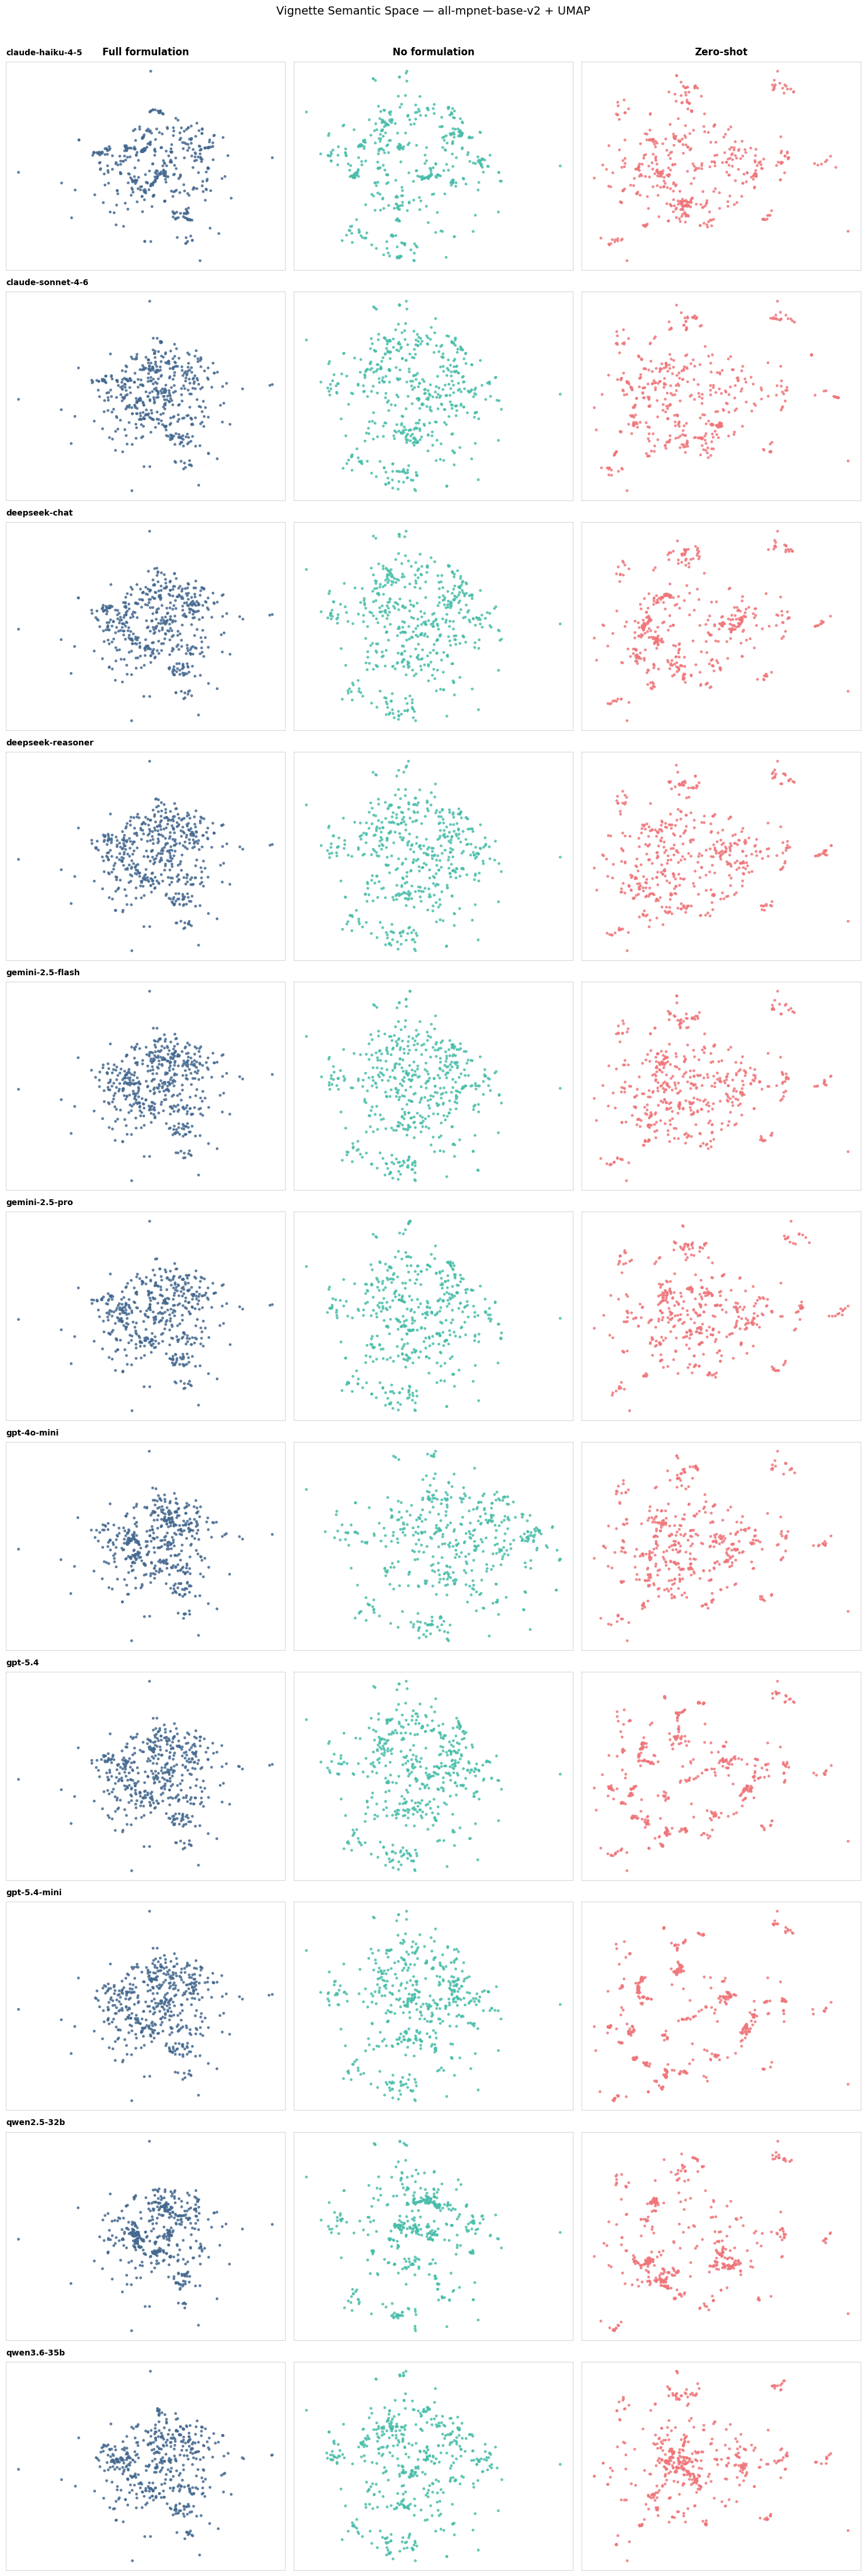

Saved -> ..\data\analysis/umap_per_model_grid_mpnet.pdf


In [12]:
import umap

UMAP_CACHE = ANALYSIS_DIR / "umap_coords_per_condition_mpnet.npz"
N_NEIGHBORS = 5

if UMAP_CACHE.exists():
    _c = np.load(UMAP_CACHE)
    umap_coords = {k: _c[k] for k in _c.files}
    print("Loaded cached UMAP coords:", list(umap_coords.keys()))
else:
    umap_coords = {}
    for cond in CONDITION_LABELS:
        idx  = df[df["condition"] == cond].index.tolist()
        embs = embeddings[idx]
        print(f"{CONDITION_LABELS[cond]}: {len(idx)} vignettes...")
        coords = umap.UMAP(n_components=2, n_neighbors=N_NEIGHBORS,
                           min_dist=0.1, random_state=42).fit_transform(embs)
        umap_coords[cond] = coords
    np.savez(UMAP_CACHE, **umap_coords)
    print(f"Saved -> {UMAP_CACHE}")

models     = sorted(df["model"].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df["condition"] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = umap_coords[cond]
        model_mask = (cond_df["model"] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors="none")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color("#cccccc")
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight="bold", pad=8)
        if c == 0:
            ax.set_title(model, loc="left", fontsize=10, fontweight="bold", pad=8)

plt.suptitle("Vignette Semantic Space — all-mpnet-base-v2 + UMAP",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_per_model_grid_mpnet.pdf", bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/umap_per_model_grid_mpnet.pdf")

## 4. t-SNE — per model × condition (cached)

Loaded cached t-SNE coords: ['full', 'no_formulation', 'zero_shot']


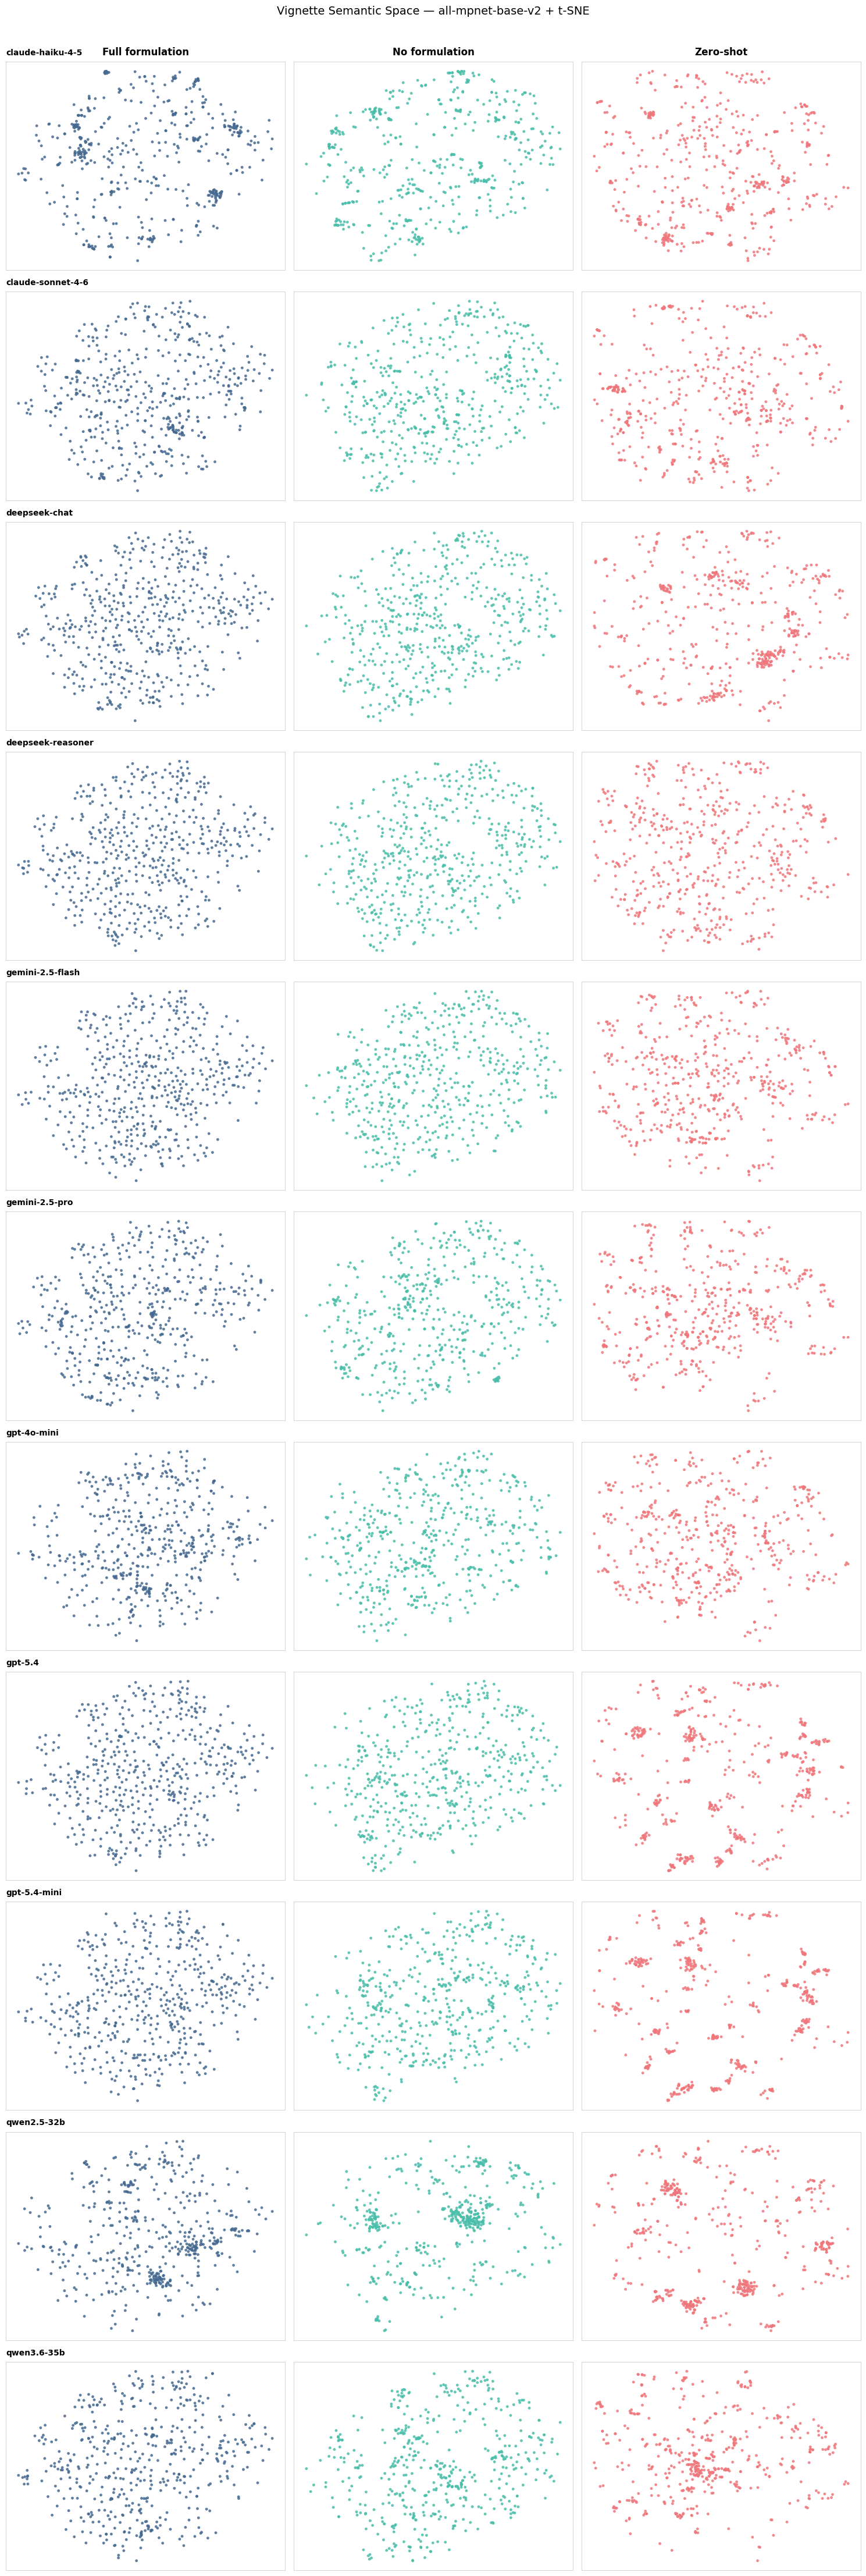

Saved -> ..\data\analysis/tsne_per_model_grid_mpnet.pdf


In [13]:
from sklearn.manifold import TSNE

TSNE_CACHE = ANALYSIS_DIR / "tsne_coords_per_condition_mpnet.npz"

if TSNE_CACHE.exists():
    _c = np.load(TSNE_CACHE)
    tsne_coords = {k: _c[k] for k in _c.files}
    print("Loaded cached t-SNE coords:", list(tsne_coords.keys()))
else:
    tsne_coords = {}
    for cond in CONDITION_LABELS:
        idx  = df[df["condition"] == cond].index.tolist()
        embs = embeddings[idx]
        print(f"{CONDITION_LABELS[cond]}: running t-SNE on {len(idx)} vignettes...")
        coords = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                      init="pca", random_state=42, n_jobs=-1).fit_transform(embs)
        tsne_coords[cond] = coords
        print(f"  done {coords.shape}")
    np.savez(TSNE_CACHE, **tsne_coords)
    print(f"Saved -> {TSNE_CACHE}")

models     = sorted(df["model"].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df["condition"] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = tsne_coords[cond]
        model_mask = (cond_df["model"] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors="none")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color("#cccccc")
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight="bold", pad=8)
        if c == 0:
            ax.set_title(model, loc="left", fontsize=10, fontweight="bold", pad=8)

plt.suptitle("Vignette Semantic Space — all-mpnet-base-v2 + t-SNE",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "tsne_per_model_grid_mpnet.pdf", bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/tsne_per_model_grid_mpnet.pdf")

## 5. Mean pairwise cosine distance — per model × condition

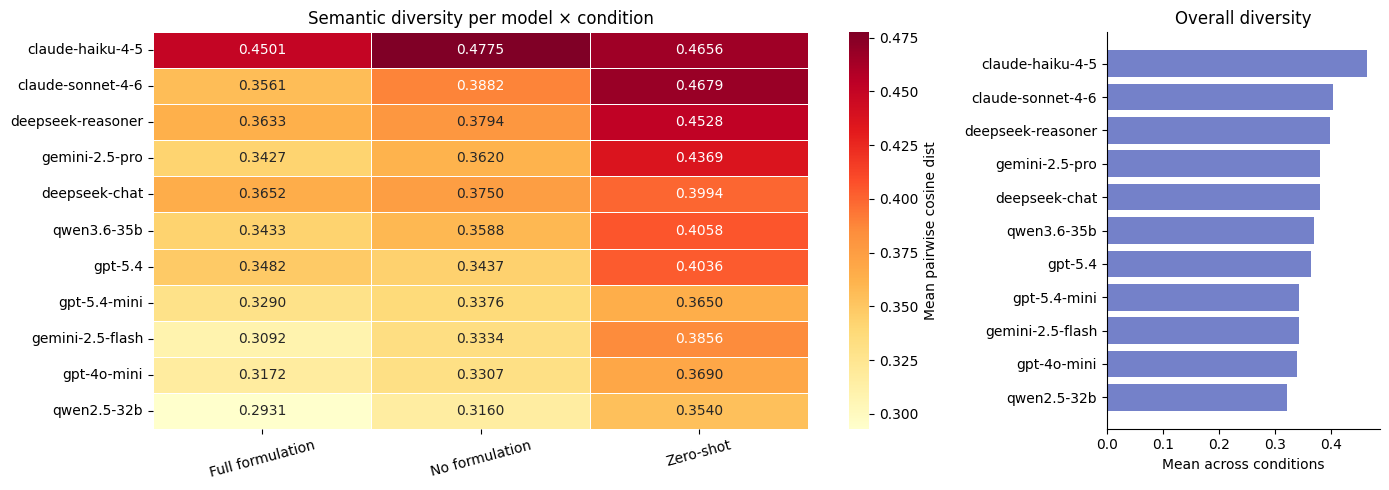

condition,Full formulation,No formulation,Zero-shot,mean
model,,,,
claude-haiku-4-5,0.4501,0.4775,0.4656,0.464400
claude-sonnet-4-6,0.3561,0.3882,0.4679,0.404067
deepseek-reasoner,0.3633,0.3794,0.4528,0.398500
gemini-2.5-pro,0.3427,0.3620,0.4369,0.380533
deepseek-chat,0.3652,0.3750,0.3994,0.379867
qwen3.6-35b,0.3433,0.3588,0.4058,0.369300
gpt-5.4,0.3482,0.3437,0.4036,0.365167
gpt-5.4-mini,0.3290,0.3376,0.3650,0.343867
gemini-2.5-flash,0.3092,0.3334,0.3856,0.342733


In [6]:
rows = []
for model in sorted(df["model"].unique()):
    for cond, label in CONDITION_LABELS.items():
        idx  = df[(df["model"] == model) & (df["condition"] == cond)].index
        embs = embeddings[idx]
        dists = pairwise_distances(embs, metric="cosine")
        upper = dists[np.triu_indices_from(dists, k=1)]
        rows.append({"model": model, "condition": label,
                     "mean_dist": round(float(upper.mean()), 4)})

cosine_df = pd.DataFrame(rows)
pivot = cosine_df.pivot(index="model", columns="condition", values="mean_dist")
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
pivot["mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

data = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=axes[0], annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Mean pairwise cosine dist"})
axes[0].set_title("Semantic diversity per model × condition", fontsize=12)
axes[0].set_xlabel(""); axes[0].set_ylabel("")
axes[0].tick_params(axis="x", rotation=15)

axes[1].barh(pivot.index, pivot["mean"], color="#5C6BC0", alpha=0.85)
axes[1].set_xlabel("Mean across conditions", fontsize=10)
axes[1].set_title("Overall diversity", fontsize=12)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "diversity_per_model_heatmap_mpnet.pdf", bbox_inches="tight")
plt.show()
pivot

## 6. Silhouette score — per condition
- **S_model**: do models produce distinct clusters within a condition?  
- **S_persona**: does persona drive semantic content?

Near +1 → label predicts clusters. Near 0 → interleaved.

Full formulation        S_model=-0.0138  S_persona=0.1219
No formulation          S_model=-0.0057  S_persona=0.0948
Zero-shot               S_model=0.0039  S_persona=0.0603


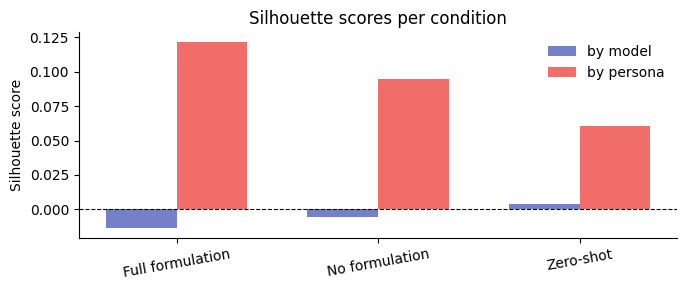

,Silhouette (model),Silhouette (persona)
Condition,,
Full formulation,-0.0138,0.1219
No formulation,-0.0057,0.0948
Zero-shot,0.0039,0.0603


In [7]:
sil_rows = []
for cond, label in CONDITION_LABELS.items():
    idx      = df[df["condition"] == cond].index
    embs     = embeddings[idx]
    labels_m = LabelEncoder().fit_transform(df.loc[idx, "model"])
    labels_p = LabelEncoder().fit_transform(df.loc[idx, "persona_id"])
    s_m = silhouette_score(embs, labels_m, metric="cosine")
    s_p = silhouette_score(embs, labels_p, metric="cosine")
    sil_rows.append({"Condition": label,
                     "Silhouette (model)": round(s_m, 4),
                     "Silhouette (persona)": round(s_p, 4)})
    print(f"{label:<22}  S_model={s_m:.4f}  S_persona={s_p:.4f}")

sil_df = pd.DataFrame(sil_rows).set_index("Condition")

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(sil_df))
w = 0.35
ax.bar(x - w/2, sil_df["Silhouette (model)"],   width=w, label="by model",   color="#5C6BC0", alpha=0.85)
ax.bar(x + w/2, sil_df["Silhouette (persona)"], width=w, label="by persona", color="#EF5350", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(sil_df.index, rotation=10)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette scores per condition")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "silhouette_mpnet.pdf", bbox_inches="tight")
plt.show()
sil_df

## 7. Vendi Score — per model × condition
Effective number of distinct vignettes. Rewards uniform spread, penalises clustering.  
Higher = more diverse.

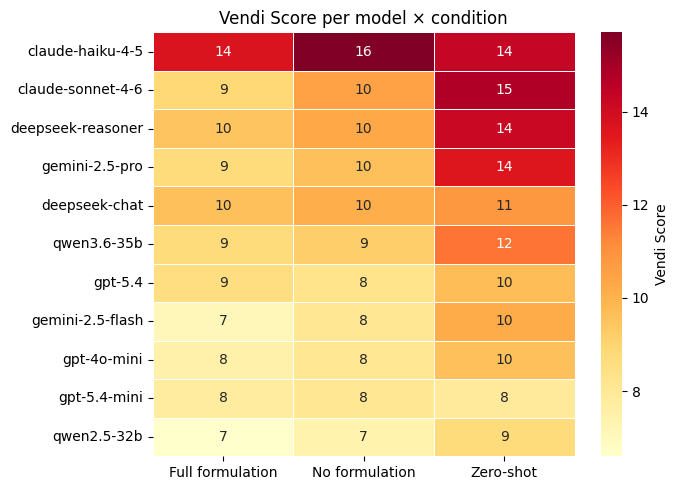

condition,Full formulation,No formulation,Zero-shot,mean
model,,,,
claude-haiku-4-5,13.7,15.7,14.3,14.566667
claude-sonnet-4-6,8.9,10.5,14.8,11.400000
deepseek-reasoner,9.5,10.3,14.2,11.333333
gemini-2.5-pro,8.7,9.6,13.6,10.633333
deepseek-chat,9.6,10.1,10.8,10.166667
qwen3.6-35b,8.7,9.2,11.6,9.833333
gpt-5.4,8.6,8.3,9.7,8.866667
gemini-2.5-flash,7.1,8.1,10.2,8.466667
gpt-4o-mini,7.5,8.1,9.6,8.400000


In [8]:
def vendi_score(embs):
    n = len(embs)
    K = embs @ embs.T
    K = K / n
    eigvals = np.linalg.eigvalsh(K)
    eigvals = eigvals[eigvals > 1e-10]
    eigvals /= eigvals.sum()
    return float(np.exp(-np.sum(eigvals * np.log(eigvals))))

rows = []
for model in sorted(df["model"].unique()):
    for cond, label in CONDITION_LABELS.items():
        idx  = df[(df["model"] == model) & (df["condition"] == cond)].index
        rows.append({"model": model, "condition": label,
                     "vendi_score": round(vendi_score(embeddings[idx]), 1)})

vendi_df = pd.DataFrame(rows)
pivot_v  = vendi_df.pivot(index="model", columns="condition", values="vendi_score")
pivot_v  = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
pivot_v["mean"] = pivot_v.mean(axis=1)
pivot_v  = pivot_v.sort_values("mean", ascending=False)
pivot_v.to_csv(ANALYSIS_DIR / "vendi_per_model_mpnet.csv")

fig, ax = plt.subplots(figsize=(7, 5))
data = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=ax, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Vendi Score"})
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Vendi Score per model × condition", fontsize=12)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "vendi_heatmap_mpnet.pdf", bbox_inches="tight")
plt.show()
pivot_v

## 8. Emotion profile — j-hartmann/emotion-english-distilroberta-base
7 Ekman emotions per vignette (anger, disgust, fear, joy, neutral, sadness, surprise).  
Cached to `emotion_scores.parquet`. Delete cache to recompute (~10–15 min on CPU).

## 10. Token usage & iteration statistics per model × condition

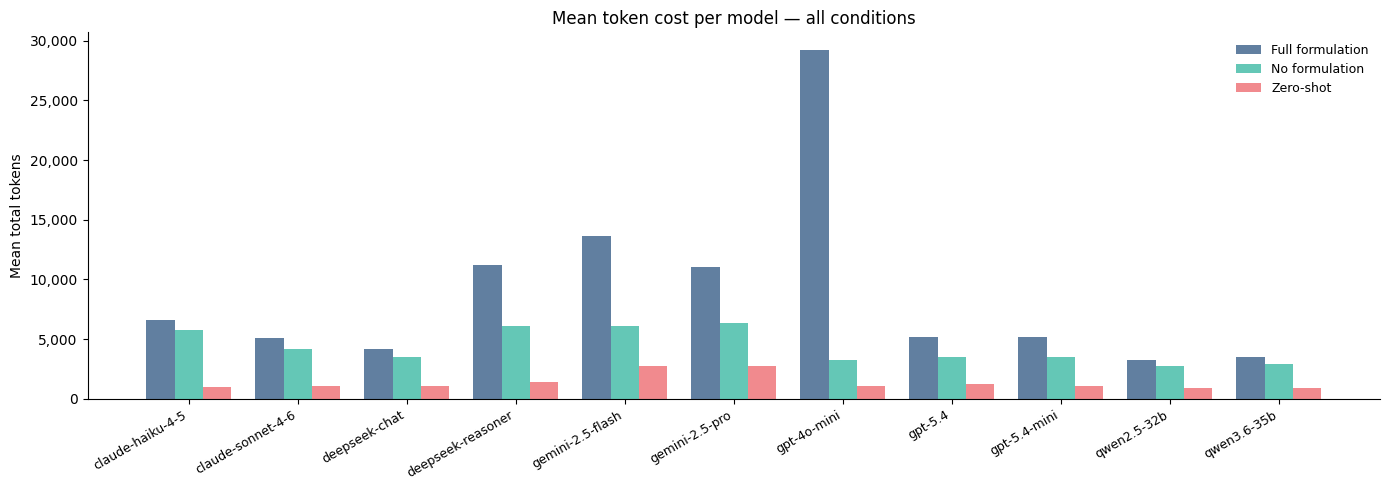

Mean total tokens per model × condition:
                   Full formulation  No formulation  Zero-shot
model                                                         
claude-haiku-4-5               6602            5768       1007
claude-sonnet-4-6              5062            4214       1062
deepseek-chat                  4159            3479       1050
deepseek-reasoner             11205            6108       1443
gemini-2.5-flash              13651            6075       2779
gemini-2.5-pro                11024            6379       2739
gpt-4o-mini                   29234            3238       1091
gpt-5.4                        5187            3539       1255
gpt-5.4-mini                   5144            3472       1111
qwen2.5-32b                    3284            2790        918
qwen3.6-35b                    3479            2919        910


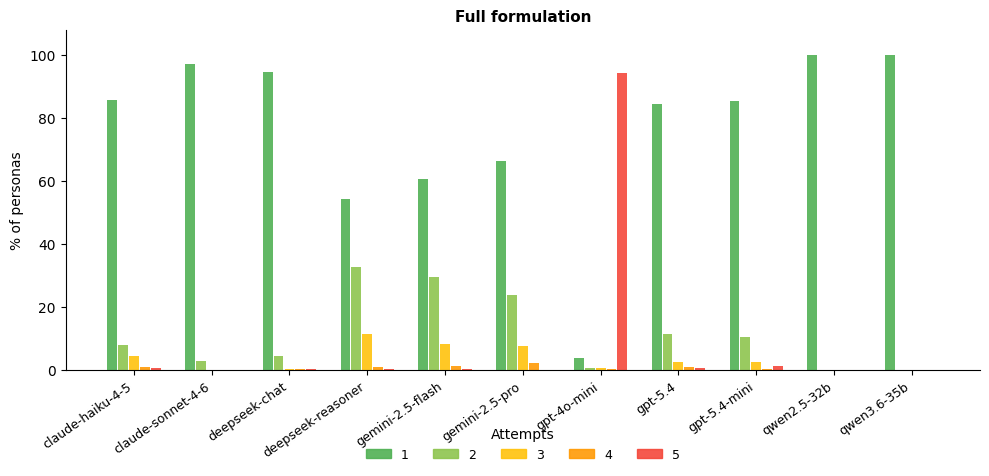

Saved: tokens_grouped_bar.pdf | iterations_grouped_bar.pdf


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

ANALYSIS_DIR = Path("../data/analysis")
CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {"full": "#456990", "no_formulation": "#49BEAA", "zero_shot": "#EF767A"}

_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

long = pd.read_csv(ANALYSIS_DIR / "personas_long.csv")
long = long[long["model"].isin(_EVAL_MODELS)]
long["condition_label"] = long["condition"].map(CONDITION_LABELS)

# ── 1. Combined grouped bar: mean tokens all 3 conditions per model ───────────
pivot_tokens = (
    long.groupby(["model", "condition"])["tokens_total"]
    .mean()
    .unstack("condition")
    [[c for c in CONDITION_LABELS if c in long["condition"].unique()]]
)
pivot_tokens.columns = [CONDITION_LABELS[c] for c in pivot_tokens.columns]
pivot_tokens = pivot_tokens.reindex([m for m in _EVAL_MODELS if m in pivot_tokens.index])

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(pivot_tokens))
w = 0.26
for i, (col, color) in enumerate(zip(pivot_tokens.columns, CONDITION_COLORS.values())):
    ax.bar(x + (i - 1) * w, pivot_tokens[col], width=w, label=col, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pivot_tokens.index, rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("Mean total tokens")
ax.set_title("Mean token cost per model — all conditions", fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "tokens_grouped_bar.pdf", bbox_inches="tight")
plt.show()

# ── 2. Mean tokens table — raw model names as in config ──────────────────────
pivot_raw = (
    long.groupby(["model", "condition"])["tokens_total"]
    .mean()
    .unstack("condition")
    [[c for c in CONDITION_LABELS if c in long["condition"].unique()]]
)
pivot_raw.columns = [CONDITION_LABELS[c] for c in pivot_raw.columns]
pivot_raw = pivot_raw.reindex([m for m in _EVAL_MODELS if m in pivot_raw.index])
print("Mean total tokens per model × condition:")
print(pivot_raw.round(0).astype("Int64").to_string(na_rep="—"))

# ── 3. Iteration distribution — grouped bar (full condition only) ─────────────
iter_df = long[long["condition"] == "full"].copy()
iter_df["n_attempts_capped"] = iter_df["n_attempts"].clip(upper=5).astype(int)

ATTEMPT_COLORS = {1: "#4CAF50", 2: "#8BC34A", 3: "#FFC107", 4: "#FF9800", 5: "#F44336"}

fig, ax = plt.subplots(figsize=(10, 5))
order = [m for m in _EVAL_MODELS if m in iter_df["model"].values]
attempt_counts = (
    iter_df.groupby(["model", "n_attempts_capped"])
    .size().unstack(fill_value=0).reindex(order)
)
attempt_pct = attempt_counts.div(attempt_counts.sum(axis=1), axis=0) * 100
attempt_cols = sorted(attempt_pct.columns)

n_attempts = len(attempt_cols)
x = np.arange(len(order))
w = 0.7 / n_attempts

for j, att in enumerate(attempt_cols):
    vals   = attempt_pct[att].values
    offset = (j - n_attempts / 2 + 0.5) * w
    ax.bar(x + offset, vals, width=w * 0.9,
           color=ATTEMPT_COLORS.get(att, "#9E9E9E"), alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=35, ha="right", fontsize=9)
ax.set_title("Full formulation", fontsize=11, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("% of personas")
ax.set_ylim(0, 108)
ax.spines[["top", "right"]].set_visible(False)

# legend below the panel
handles = [mpatches.Patch(color=ATTEMPT_COLORS.get(a, "#9E9E9E"), alpha=0.88,
                          label=str(a))
           for a in attempt_cols]
ax.legend(handles=handles, title="Attempts", ncol=len(handles),
          loc="lower center", bbox_to_anchor=(0.5, -0.30), fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "iterations_grouped_bar.pdf", bbox_inches="tight")
plt.show()
print(f"Saved: tokens_grouped_bar.pdf | iterations_grouped_bar.pdf")


## 9. Persona identity preservation
For each persona, how similar are the vignettes generated by different models?  
**Within-persona** = same persona, different models. **Between-persona** = different personas, same condition.  
Higher within-persona similarity → models agree on how to portray that persona.

Loaded 16500 vignettes + embeddings


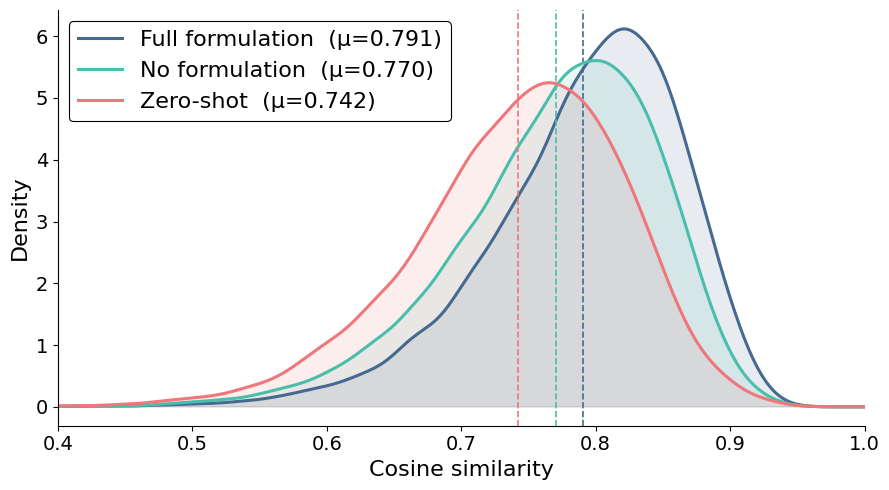


Paired t-tests on per-persona mean similarity (n = 500 personas)

Comparison                                     Δμ        t     df           p   Cohen d  sig
───────────────────────────────────────────────────────────────────────────────────────────────
Full formulation  vs  No formulation      +0.0205    16.36    499    1.75e-48   +0.7317  ***
Full formulation  vs  Zero-shot           +0.0486    31.53    499   7.85e-121   +1.4099  ***
No formulation  vs  Zero-shot             +0.0280    19.01    499    5.08e-61   +0.8502  ***

Effect size interpretation: |d| < 0.2 small, 0.2–0.5 medium, > 0.5 large


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from pathlib import Path
from scipy.stats import gaussian_kde, ttest_rel
from scipy.stats import t as t_dist

ANALYSIS_DIR = Path("../data/analysis")
CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {"full": "#456990", "no_formulation": "#49BEAA", "zero_shot": "#EF767A"}

_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

# ── 0. Load from cache ────────────────────────────────────────────────────────
_df         = pd.read_parquet(ANALYSIS_DIR / "all_vignettes.parquet")
_embeddings = np.load(ANALYSIS_DIR / "embeddings_mpnet.npy")
_df = _df[_df["model"].isin(_EVAL_MODELS)].copy()
print(f"Loaded {len(_df)} vignettes + embeddings")

# ── 1. Collect within-persona cross-model similarities per condition ──────────
# cond_sims:       all raw pair similarities  (for KDE)
# persona_means:   mean similarity per persona (for hypothesis test)
cond_sims    = {c: [] for c in CONDITION_LABELS}
persona_means = {c: {} for c in CONDITION_LABELS}   # pid -> mean sim

for cond in CONDITION_LABELS:
    cond_df   = _df[_df["condition"] == cond].reset_index()
    cond_embs = _embeddings[cond_df["index"].values]
    cond_df   = cond_df.reset_index(drop=True)

    pid_model_idx = {}
    for i, row in cond_df.iterrows():
        pid_model_idx.setdefault(row["persona_id"], {})[row["model"]] = i

    for pid, model_map in pid_model_idx.items():
        models_present = list(model_map.keys())
        sims_for_pid = []
        for m1, m2 in combinations(models_present, 2):
            i1, i2 = model_map[m1], model_map[m2]
            s = float(cond_embs[i1] @ cond_embs[i2])
            cond_sims[cond].append(s)
            sims_for_pid.append(s)
        if sims_for_pid:
            persona_means[cond][pid] = np.mean(sims_for_pid)

# ── 2. KDE plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x_grid = np.linspace(0.0, 1.0, 500)

for cond, label in CONDITION_LABELS.items():
    sims = cond_sims[cond]
    col  = CONDITION_COLORS[cond]
    kde  = gaussian_kde(sims, bw_method=0.15)
    y    = kde(x_grid)
    mu   = np.mean(sims)
    ax.plot(x_grid, y, color=col, linewidth=2.2, label=f"{label}  (μ={mu:.3f})")
    ax.fill_between(x_grid, y, alpha=0.12, color=col)
    ax.axvline(mu, color=col, linewidth=1.2, linestyle="--")

ax.set_xlim(0.4, 1.0)
ax.set_xlabel("Cosine similarity", fontsize=16)
ax.set_ylabel("Density", fontsize=16)
ax.tick_params(axis="both", labelsize=14)
leg = ax.legend(frameon=True, fontsize=16, edgecolor="black", framealpha=1.0)
leg.get_frame().set_linewidth(0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "persona_identity_distributions.pdf", bbox_inches="tight")
plt.show()

# ── 3. Paired t-tests on per-persona means (500 independent observations) ────
# Using paired t-test: same 500 personas appear in all 3 conditions
conds = list(CONDITION_LABELS.keys())
pairs = list(combinations(conds, 2))

def cohens_d(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

print("\nPaired t-tests on per-persona mean similarity (n = 500 personas)\n")
print(f"{'Comparison':<40}  {'Δμ':>7}  {'t':>7}  {'df':>5}  {'p':>10}  {'Cohen d':>8}  {'sig'}")
print("─" * 95)

for c1, c2 in pairs:
    pids  = sorted(set(persona_means[c1]) & set(persona_means[c2]))
    a     = np.array([persona_means[c1][p] for p in pids])
    b     = np.array([persona_means[c2][p] for p in pids])
    t_stat, p_val = ttest_rel(a, b)
    d     = cohens_d(a, b)
    delta = a.mean() - b.mean()
    sig   = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    label = f"{CONDITION_LABELS[c1]}  vs  {CONDITION_LABELS[c2]}"
    print(f"{label:<40}  {delta:>+7.4f}  {t_stat:>7.2f}  {len(pids)-1:>5}  {p_val:>10.2e}  {d:>+8.4f}  {sig}")

print("\nEffect size interpretation: |d| < 0.2 small, 0.2–0.5 medium, > 0.5 large")


Loaded cached emotion scores: 14981 rows
                anger  disgust   fear    joy  neutral  sadness  surprise
condition                                                               
full            0.035    0.099  0.802  0.001    0.025    0.029     0.009
no_formulation  0.031    0.121  0.774  0.001    0.033    0.029     0.012
zero_shot       0.034    0.158  0.615  0.002    0.129    0.045     0.017


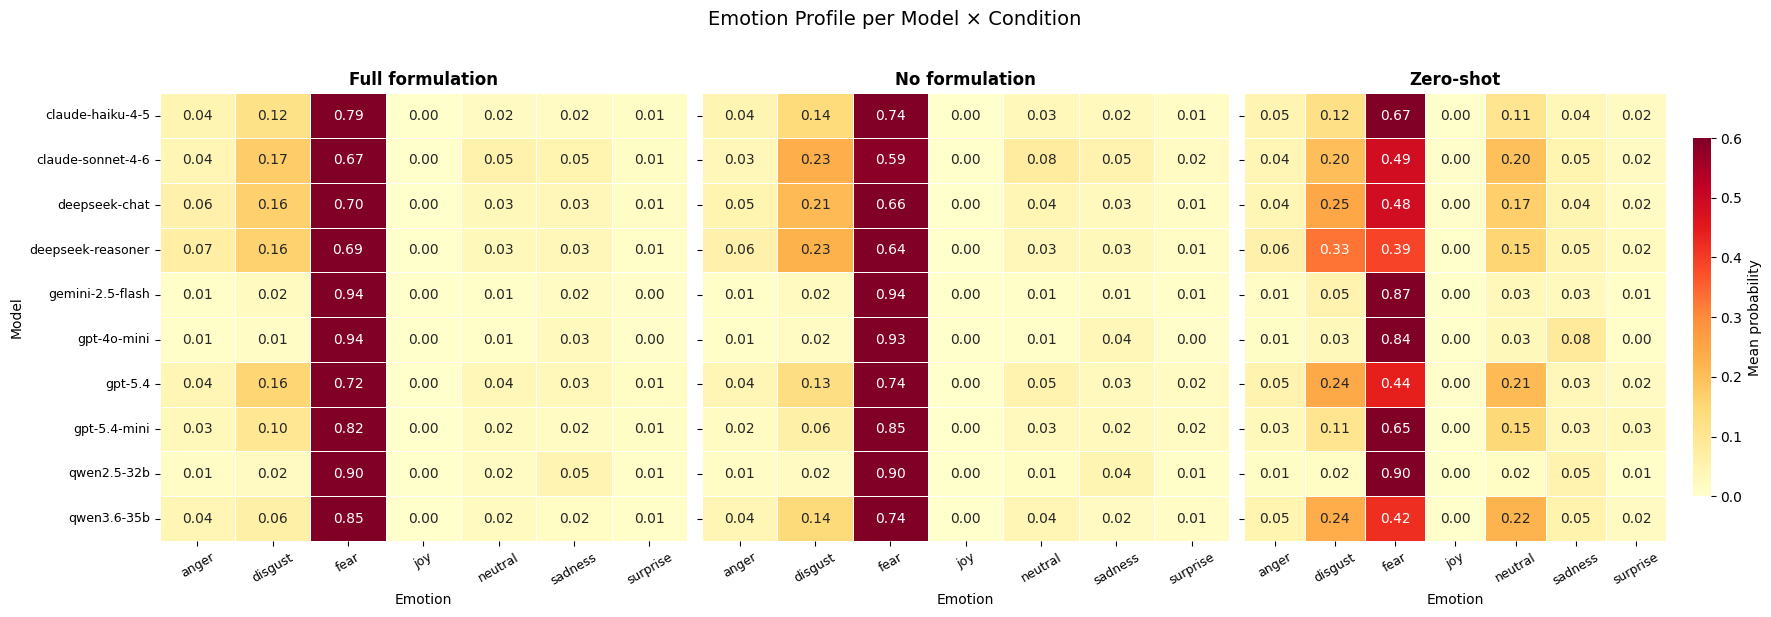

Saved -> ..\data\analysis/emotion_heatmap.pdf


In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import pipeline

ANALYSIS_DIR  = Path("../data/analysis")
EMO_CACHE     = ANALYSIS_DIR / "emotion_scores.parquet"

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
EMOTIONS = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

# ── 1. Compute or load ────────────────────────────────────────────────────────
if EMO_CACHE.exists():
    emo_df = pd.read_parquet(EMO_CACHE)
    print(f"Loaded cached emotion scores: {len(emo_df)} rows")
else:
    vig_cache = ANALYSIS_DIR / "all_vignettes.parquet"
    df_v = pd.read_parquet(vig_cache)
    print(f"Scoring {len(df_v)} vignettes...")

    clf = pipeline(
        "text-classification",
        model="j-hartmann/emotion-english-distilroberta-base",
        top_k=None,
        truncation=True,
        max_length=512,
        device=-1,       # CPU; set device=0 for GPU
    )

    records = []
    batch_size = 32
    texts = df_v["vignette"].tolist()
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        results = clf(batch)
        for j, res in enumerate(results):
            row = {r["label"]: r["score"] for r in res}
            row["_idx"] = i + j
            records.append(row)
        if i % 1000 == 0:
            print(f"  {i}/{len(texts)}")

    scores = pd.DataFrame(records).set_index("_idx").reindex(columns=EMOTIONS).fillna(0)
    emo_df = pd.concat([df_v[["persona_id", "model", "condition"]].reset_index(drop=True),
                        scores.reset_index(drop=True)], axis=1)
    emo_df.to_parquet(EMO_CACHE, index=False)
    print(f"Saved -> {EMO_CACHE}")

print(emo_df.groupby("condition")[EMOTIONS].mean().round(3))

# ── 2. Heatmap: mean emotion per model × condition ────────────────────────────
_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (cond, label) in zip(axes, CONDITION_LABELS.items()):
    sub = emo_df[(emo_df["condition"] == cond) & (emo_df["model"].isin(_EVAL_MODELS))]
    pivot = sub.groupby("model")[EMOTIONS].mean().reindex(_EVAL_MODELS)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=0.6, linewidths=0.4,
                cbar=(ax == axes[-1]),
                cbar_kws={"label": "Mean probability", "shrink": 0.8})
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Emotion"); ax.set_ylabel("" if ax != axes[0] else "Model")
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Emotion Profile per Model × Condition", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "emotion_heatmap.pdf", bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/emotion_heatmap.pdf")



## 12. LLM Judge Ratings Analysis (n = 330)
Judge: `claude-opus-4-5` · 11 models × 3 conditions × 10 vignettes each  
**Likert (1–3):** clarity, relevance, importance, g1–g4 (construction quality)  
**Binary (0/1):** DSM-5 criteria A/B/C/D/E/G · E&C components (threat, appraisals, memory, strategies, triggers)

Loaded 330 judge ratings
model           claude-haiku-4-5  claude-sonnet-4-6  deepseek-chat  deepseek-reasoner  gemini-2.5-flash  gemini-2.5-pro  gpt-4o-mini  gpt-5.4  gpt-5.4-mini  qwen2.5-32b  qwen3.6-35b
condition                                                                                                                                                                            
full                          10                 10             10                 10                10              10           10       10            10           10           10
no_formulation                10                 10             10                 10                10              10           10       10            10           10           10
zero_shot                     10                 10             10                 10                10              10           10       10            10           10           10

Mean Likert scores by condition (1–3):
                  clarity

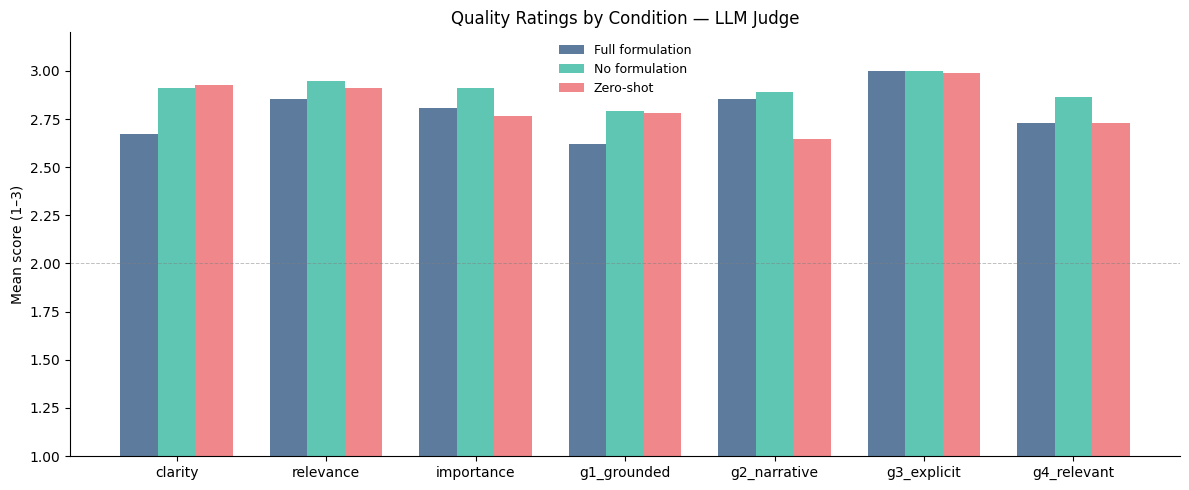


Kruskal-Wallis + pairwise Mann-Whitney (Bonferroni) on Likert scores

clarity             KW p=1.281e-05  ***
  Full formulation       vs No formulation          Δμ=-0.236  p_bon=1.061e-03  **
  Full formulation       vs Zero-shot               Δμ=-0.255  p_bon=2.056e-04  ***
  No formulation         vs Zero-shot               Δμ=-0.018  p_bon=1.000e+00  ns
relevance           KW p=7.265e-02  ns
  Full formulation       vs No formulation          Δμ=-0.091  p_bon=7.524e-02  ns
  Full formulation       vs Zero-shot               Δμ=-0.055  p_bon=6.357e-01  ns
  No formulation         vs Zero-shot               Δμ=+0.036  p_bon=9.037e-01  ns
importance          KW p=1.427e-02  *
  Full formulation       vs No formulation          Δμ=-0.100  p_bon=1.008e-01  ns
  Full formulation       vs Zero-shot               Δμ=+0.045  p_bon=1.000e+00  ns
  No formulation         vs Zero-shot               Δμ=+0.145  p_bon=1.093e-02  *
g1_grounded         KW p=4.772e-02  *
  Full formulation       vs

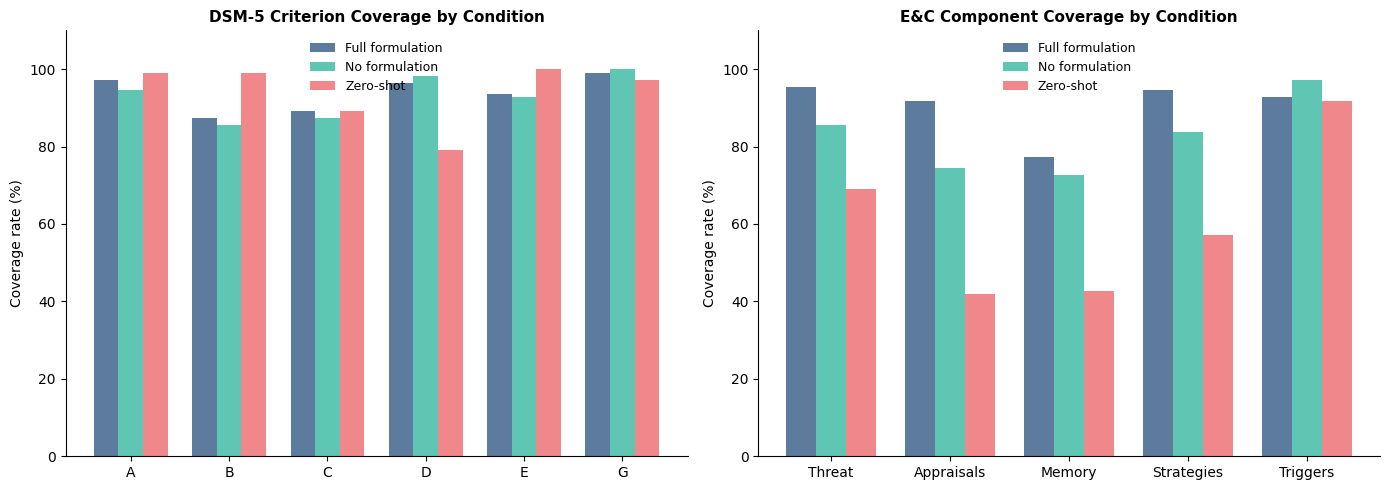

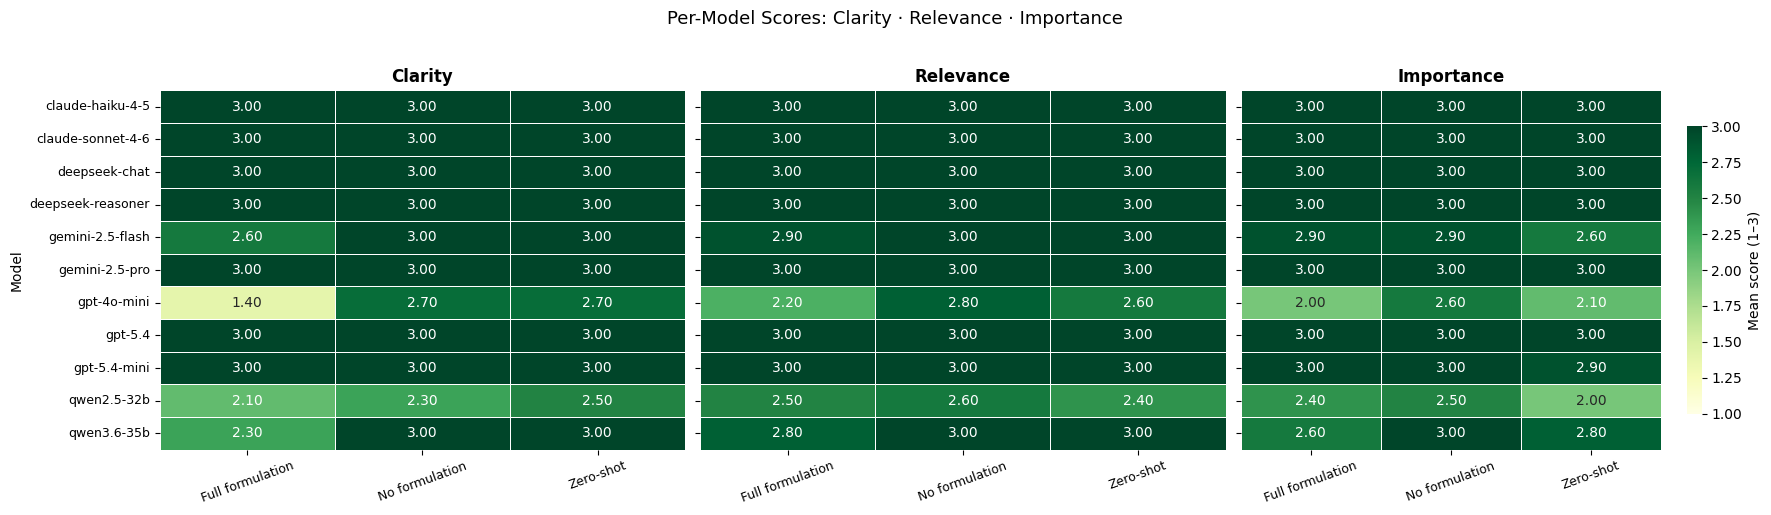


Saved: judge_likert_by_condition.pdf | judge_coverage_by_condition.pdf | judge_model_heatmap_cri.pdf


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

JUDGE_PATH = Path("../data/llm_judge_v10/llm_judge_claude-opus-4-5.csv")
ANALYSIS_DIR = Path("../data/analysis")

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {"full": "#456990", "no_formulation": "#49BEAA", "zero_shot": "#EF767A"}

_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

LIKERT_COLS = ["clarity", "relevance", "importance",
               "g1_grounded", "g2_narrative", "g3_explicit", "g4_relevant"]
DSM_COLS    = ["dsm_a", "dsm_b", "dsm_c", "dsm_d", "dsm_e", "dsm_g"]
EC_COLS     = ["ec_threat", "ec_appraisals", "ec_memory", "ec_strategies", "ec_triggers"]

jdf = pd.read_csv(JUDGE_PATH)
jdf["condition_label"] = jdf["condition"].map(CONDITION_LABELS)
print(f"Loaded {len(jdf)} judge ratings")
print(jdf.groupby(["condition", "model"]).size().unstack(fill_value=0).to_string())

# ── 1. Condition means — Likert ───────────────────────────────────────────────
cond_means = jdf.groupby("condition")[LIKERT_COLS].mean()
cond_means = cond_means.loc[[c for c in CONDITION_LABELS if c in cond_means.index]]
cond_means.index = [CONDITION_LABELS[c] for c in cond_means.index]
print("\nMean Likert scores by condition (1–3):")
print(cond_means.round(3).to_string())

# ── 2. Grouped bar: mean Likert per condition ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(LIKERT_COLS))
w = 0.25
for i, (cond, label) in enumerate(CONDITION_LABELS.items()):
    vals = [jdf[jdf["condition"] == cond][col].mean() for col in LIKERT_COLS]
    ax.bar(x + (i - 1) * w, vals, width=w, label=label,
           color=CONDITION_COLORS[cond], alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(LIKERT_COLS, fontsize=10)
ax.set_ylim(1, 3.2)
ax.set_ylabel("Mean score (1–3)")
ax.set_title("Quality Ratings by Condition — LLM Judge", fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.axhline(2, color="grey", linewidth=0.7, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_likert_by_condition.pdf", bbox_inches="tight")
plt.show()

# ── 3. Kruskal-Wallis + pairwise Mann-Whitney on each Likert metric ───────────
print("\nKruskal-Wallis + pairwise Mann-Whitney (Bonferroni) on Likert scores\n")
cond_keys = list(CONDITION_LABELS.keys())
pairs = list(combinations(cond_keys, 2))

for col in LIKERT_COLS:
    groups = [jdf[jdf["condition"] == c][col].dropna().values for c in cond_keys]
    stat, p = kruskal(*groups)
    print(f"{col:<18}  KW p={p:.3e}  {'***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'}")
    for c1, c2 in pairs:
        g1 = jdf[jdf["condition"] == c1][col].dropna().values
        g2 = jdf[jdf["condition"] == c2][col].dropna().values
        _, p_mw = mannwhitneyu(g1, g2, alternative="two-sided")
        p_bon = min(p_mw * len(pairs), 1.0)
        d = (g1.mean() - g2.mean())
        sig = "***" if p_bon<.001 else "**" if p_bon<.01 else "*" if p_bon<.05 else "ns"
        print(f"  {CONDITION_LABELS[c1]:<22} vs {CONDITION_LABELS[c2]:<22}  Δμ={d:+.3f}  p_bon={p_bon:.3e}  {sig}")

# ── 4. DSM criterion coverage by condition ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dsm_rates = jdf.groupby("condition")[DSM_COLS].mean() * 100
dsm_rates = dsm_rates.loc[[c for c in CONDITION_LABELS if c in dsm_rates.index]]
dsm_rates.index = [CONDITION_LABELS[c] for c in dsm_rates.index]

x = np.arange(len(DSM_COLS))
for i, (cond, label) in enumerate(CONDITION_LABELS.items()):
    key = CONDITION_LABELS[cond]
    if key in dsm_rates.index:
        axes[0].bar(x + (i - 1) * 0.25, dsm_rates.loc[key], width=0.25,
                    label=label, color=CONDITION_COLORS[cond], alpha=0.88)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.upper().replace("DSM_", "") for c in DSM_COLS], fontsize=10)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Coverage rate (%)")
axes[0].set_title("DSM-5 Criterion Coverage by Condition", fontsize=11, fontweight="bold")
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

# ── 5. E&C component coverage by condition ────────────────────────────────────
ec_rates = jdf.groupby("condition")[EC_COLS].mean() * 100
ec_rates = ec_rates.loc[[c for c in CONDITION_LABELS if c in ec_rates.index]]
ec_rates.index = [CONDITION_LABELS[c] for c in ec_rates.index]
ec_labels = [c.replace("ec_", "").capitalize() for c in EC_COLS]

x = np.arange(len(EC_COLS))
for i, (cond, label) in enumerate(CONDITION_LABELS.items()):
    key = CONDITION_LABELS[cond]
    if key in ec_rates.index:
        axes[1].bar(x + (i - 1) * 0.25, ec_rates.loc[key], width=0.25,
                    label=label, color=CONDITION_COLORS[cond], alpha=0.88)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ec_labels, fontsize=10)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel("Coverage rate (%)")
axes[1].set_title("E&C Component Coverage by Condition", fontsize=11, fontweight="bold")
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_coverage_by_condition.pdf", bbox_inches="tight")
plt.show()

# ── 6. Per-model heatmaps: clarity · relevance · importance ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

cond_col_order = [CONDITION_LABELS[c] for c in CONDITION_LABELS]

for ax, metric in zip(axes, ["clarity", "relevance", "importance"]):
    pivot = (
        jdf.groupby(["model", "condition"])[metric].mean()
        .unstack("condition")[[c for c in CONDITION_LABELS if c in jdf["condition"].unique()]]
    )
    pivot.columns = [CONDITION_LABELS[c] for c in pivot.columns]
    pivot = pivot.reindex(_EVAL_MODELS)

    sns.heatmap(
        pivot, ax=ax, annot=True, fmt=".2f", cmap="YlGn",
        vmin=1, vmax=3, linewidths=0.4,
        cbar=(ax == axes[-1]),
        cbar_kws={"label": "Mean score (1–3)", "shrink": 0.8},
    )
    ax.set_title(metric.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Model" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Per-Model Scores: Clarity · Relevance · Importance", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_model_heatmap_cri.pdf", bbox_inches="tight")
plt.show()

print(f"\nSaved: judge_likert_by_condition.pdf | judge_coverage_by_condition.pdf | judge_model_heatmap_cri.pdf")

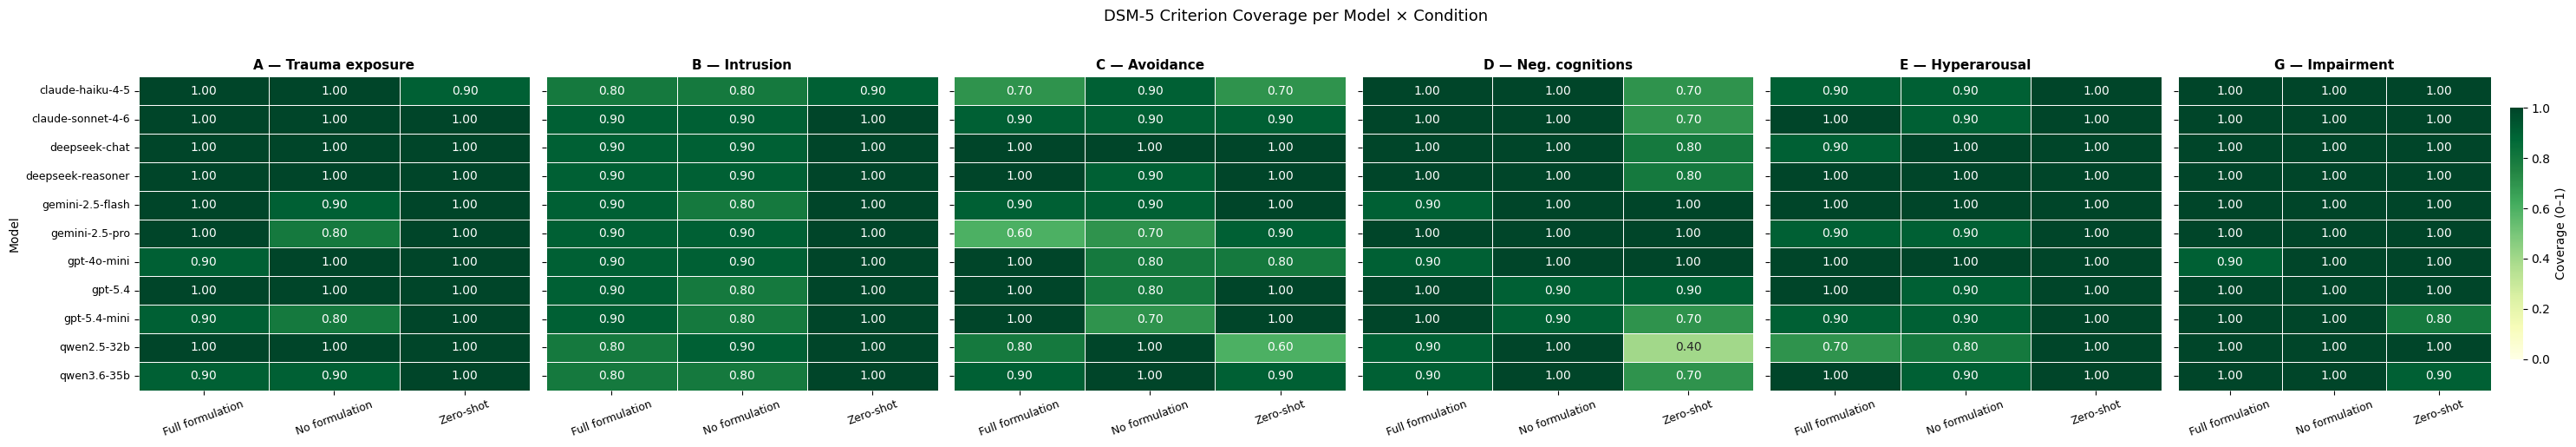

Saved -> ..\data\analysis\judge_dsm_heatmap.pdf


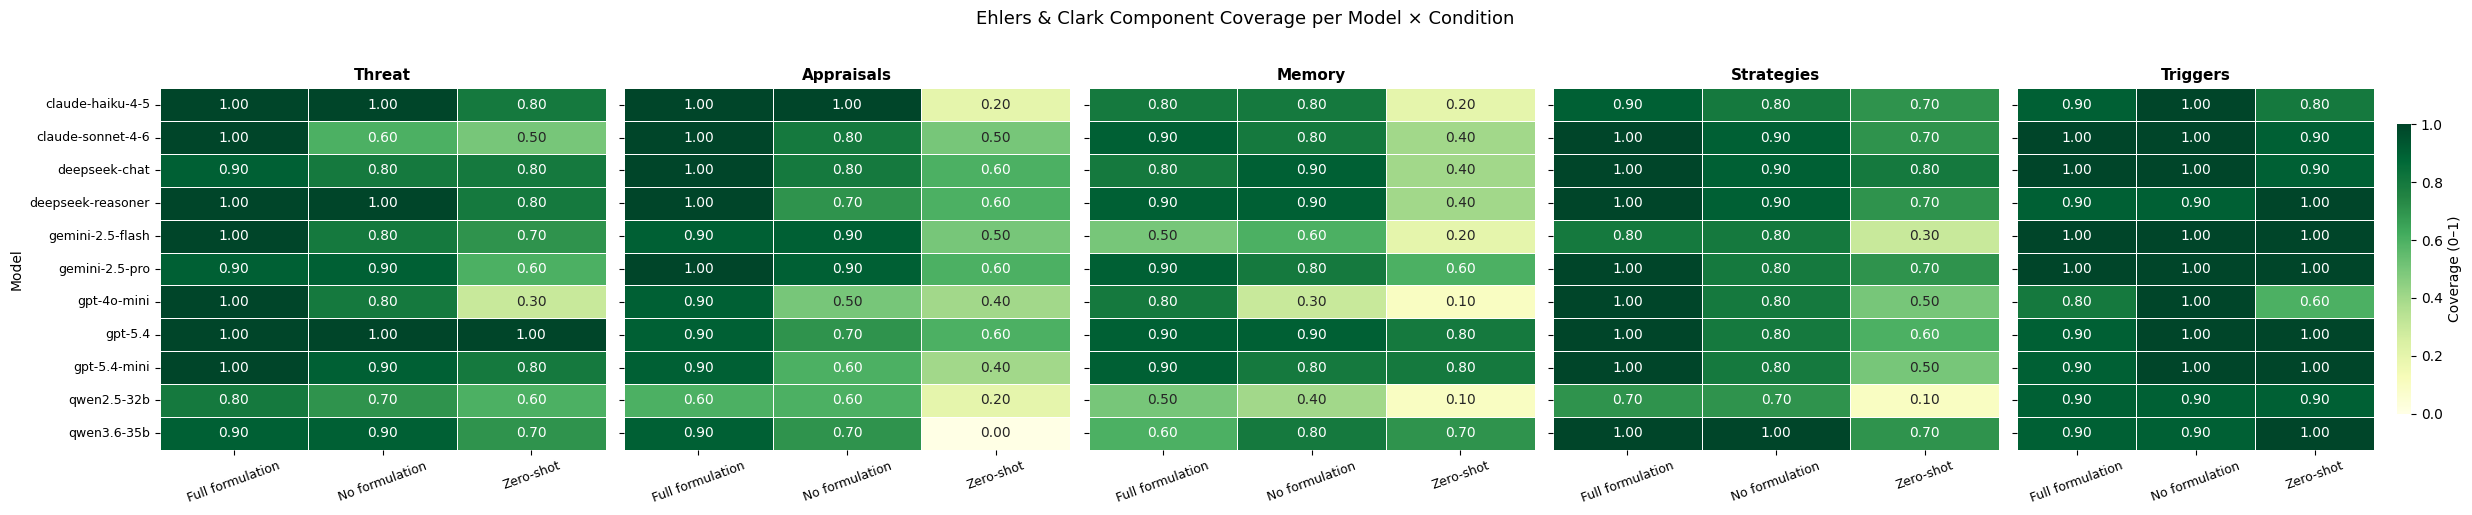

Saved -> ..\data\analysis\judge_ec_heatmap.pdf


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

JUDGE_PATH   = Path("../data/llm_judge_v10/llm_judge_claude-opus-4-5.csv")
ANALYSIS_DIR = Path("../data/analysis")

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

DSM_COLS = ["dsm_a", "dsm_b", "dsm_c", "dsm_d", "dsm_e", "dsm_g"]
EC_COLS  = ["ec_threat", "ec_appraisals", "ec_memory", "ec_strategies", "ec_triggers"]

DSM_LABELS = {
    "dsm_a": "A — Trauma exposure",
    "dsm_b": "B — Intrusion",
    "dsm_c": "C — Avoidance",
    "dsm_d": "D — Neg. cognitions",
    "dsm_e": "E — Hyperarousal",
    "dsm_g": "G — Impairment",
}
EC_LABELS = {
    "ec_threat":      "Threat",
    "ec_appraisals":  "Appraisals",
    "ec_memory":      "Memory",
    "ec_strategies":  "Strategies",
    "ec_triggers":    "Triggers",
}

jdf = pd.read_csv(JUDGE_PATH)

def coverage_heatmap(cols, label_map, title, fname):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(n * 5, 5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        pivot = (
            jdf.groupby(["model", "condition"])[col].mean()
            .unstack("condition")[[c for c in CONDITION_LABELS if c in jdf["condition"].unique()]]
        )
        pivot.columns = [CONDITION_LABELS[c] for c in pivot.columns]
        pivot = pivot.reindex(_EVAL_MODELS)

        sns.heatmap(
            pivot, ax=ax, annot=True, fmt=".2f", cmap="YlGn" \
            "",
            vmin=0, vmax=1, linewidths=0.4,
            cbar=(ax == axes[-1]),
            cbar_kws={"label": "Coverage (0–1)", "shrink": 0.8},
        )
        ax.set_title(label_map[col], fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Model" if ax == axes[0] else "")
        ax.tick_params(axis="x", rotation=20, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)

    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / fname, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {ANALYSIS_DIR / fname}")

# ── DSM-5 criteria ────────────────────────────────────────────────────────────
coverage_heatmap(
    DSM_COLS, DSM_LABELS,
    "DSM-5 Criterion Coverage per Model × Condition",
    "judge_dsm_heatmap.pdf",
)

# ── Ehlers & Clark components ─────────────────────────────────────────────────
coverage_heatmap(
    EC_COLS, EC_LABELS,
    "Ehlers & Clark Component Coverage per Model × Condition",
    "judge_ec_heatmap.pdf",
)

## 13. Inter-judge agreement: Claude Opus vs DeepSeek-v4-pro (n = 330)
Both judges rated the same 330 vignettes (11 models × 3 conditions × 10 each).  
We compare per-metric means and quantify concordance with **Cohen's κ** (unweighted for binary criteria, quadratic-weighted for ordinal Likert).

κ interpretation: < 0.2 poor · 0.2–0.4 fair · 0.4–0.6 moderate · 0.6–0.8 substantial · > 0.8 almost perfect.

In [11]:
# ── Cell 1: Load + align both judges on the 330-vignette set ─────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ANALYSIS_DIR = Path("../data/analysis")
JUDGE_V10    = Path("../data/llm_judge_v10")

opus = pd.read_csv(JUDGE_V10 / "llm_judge_claude-opus-4-5.csv")
ds   = pd.read_csv(JUDGE_V10 / "llm_judge_deepseek-v4-pro.csv")
print(f"Opus rows:     {len(opus)}")
print(f"DeepSeek rows: {len(ds)}")

# Align on vignette_id → one row per vignette with both judges side by side
merged = opus.merge(ds, on="vignette_id", suffixes=("_opus", "_ds"))
merged["model"]     = merged["model_opus"]
merged["condition"] = merged["condition_opus"]
print(f"\nAligned vignettes: {len(merged)}")

# Metric column groups (same schema for both judges)
LIKERT_COLS = ["clarity", "relevance", "importance",
               "g1_grounded", "g2_narrative", "g3_explicit", "g4_relevant"]
DSM_COLS    = ["dsm_a", "dsm_b", "dsm_c", "dsm_d", "dsm_e", "dsm_g"]
EC_COLS     = ["ec_threat", "ec_appraisals", "ec_memory", "ec_strategies", "ec_triggers"]
BINARY_COLS = DSM_COLS + EC_COLS
print(f"Likert metrics: {len(LIKERT_COLS)}  |  Binary criteria: {len(BINARY_COLS)}")


Opus rows:     330
DeepSeek rows: 330

Aligned vignettes: 330
Likert metrics: 7  |  Binary criteria: 11


Mean score per metric — Opus vs DeepSeek-v4-pro:
       metric   kind  opus_mean  deepseek_mean  delta
      clarity Likert      2.836          2.903 -0.067
    relevance Likert      2.903          2.967 -0.064
   importance Likert      2.827          2.812  0.015
  g1_grounded Likert      2.730          2.806 -0.076
 g2_narrative Likert      2.797          2.806 -0.009
  g3_explicit Likert      2.997          2.997  0.000
  g4_relevant Likert      2.773          2.752  0.021
        dsm_a    DSM      0.970          0.876  0.094
        dsm_b    DSM      0.906          0.900  0.006
        dsm_c    DSM      0.885          0.870  0.015
        dsm_d    DSM      0.912          0.942 -0.030
        dsm_e    DSM      0.955          0.967 -0.012
        dsm_g    DSM      0.988          0.994 -0.006
    ec_threat    E&C      0.833          0.670  0.164
ec_appraisals    E&C      0.694          0.712 -0.018
    ec_memory    E&C      0.642          0.606  0.036
ec_strategies    E&C      0.785  

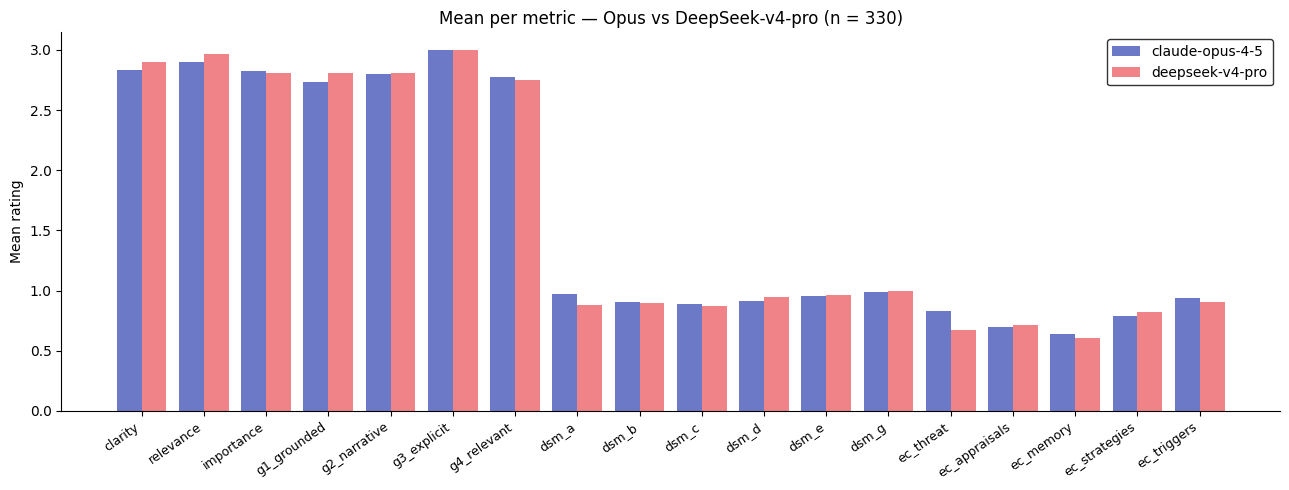

In [12]:
# ── Cell 2: Mean score per metric — side-by-side comparison ──────────────────
rows = []
for col in LIKERT_COLS + BINARY_COLS:
    rows.append({
        "metric":        col,
        "kind":          "Likert" if col in LIKERT_COLS else ("DSM" if col in DSM_COLS else "E&C"),
        "opus_mean":     merged[f"{col}_opus"].mean(),
        "deepseek_mean": merged[f"{col}_ds"].mean(),
    })
cmp = pd.DataFrame(rows)
cmp["delta"] = cmp["opus_mean"] - cmp["deepseek_mean"]
print("Mean score per metric — Opus vs DeepSeek-v4-pro:")
print(cmp.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(cmp))
w = 0.4
ax.bar(x - w/2, cmp["opus_mean"],     width=w, label="claude-opus-4-5", color="#5C6BC0", alpha=0.9)
ax.bar(x + w/2, cmp["deepseek_mean"], width=w, label="deepseek-v4-pro", color="#EF767A", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(cmp["metric"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Mean rating")
ax.set_title("Mean per metric — Opus vs DeepSeek-v4-pro (n = 330)")
ax.legend(frameon=True, edgecolor="black", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_vs_judge_means.pdf", bbox_inches="tight")
plt.show()


Cohen's κ — binary criteria (Opus vs DeepSeek-v4-pro):
    criterion kind  kappa  opus_rate  ds_rate   n
        dsm_b  DSM  0.758      0.906    0.900 330
ec_appraisals  E&C  0.623      0.694    0.712 330
        dsm_e  DSM  0.600      0.955    0.967 330
        dsm_c  DSM  0.592      0.885    0.870 330
  ec_triggers  E&C  0.555      0.939    0.906 330
    ec_memory  E&C  0.548      0.642    0.606 330
        dsm_d  DSM  0.507      0.912    0.942 330
    ec_threat  E&C  0.358      0.833    0.670 330
ec_strategies  E&C  0.306      0.785    0.818 330
        dsm_a  DSM  0.237      0.970    0.876 330
        dsm_g  DSM -0.008      0.988    0.994 330


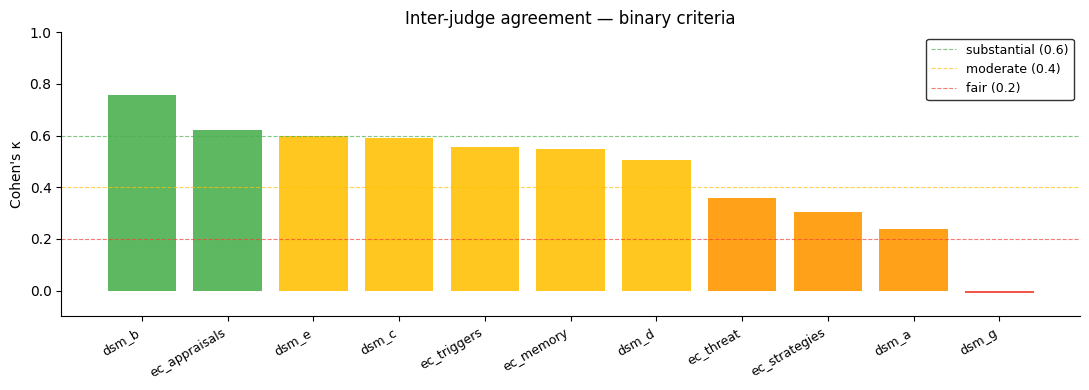

In [13]:
# ── Cell 3: Cohen's κ on binary criteria (DSM + E&C) ─────────────────────────
from sklearn.metrics import cohen_kappa_score

rows = []
for col in BINARY_COLS:
    a = merged[f"{col}_opus"].astype(int).values
    b = merged[f"{col}_ds"].astype(int).values
    rows.append({
        "criterion": col,
        "kind":      "DSM" if col in DSM_COLS else "E&C",
        "kappa":     cohen_kappa_score(a, b),
        "opus_rate": a.mean(),
        "ds_rate":   b.mean(),
        "n":         len(a),
    })
kdf = pd.DataFrame(rows).sort_values("kappa", ascending=False)
print("Cohen's κ — binary criteria (Opus vs DeepSeek-v4-pro):")
print(kdf.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(kdf))
def _bar_color(k):
    return "#4CAF50" if k > 0.6 else "#FFC107" if k > 0.4 else "#FF9800" if k > 0.2 else "#F44336"
ax.bar(x, kdf["kappa"], color=[_bar_color(k) for k in kdf["kappa"]], alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(kdf["criterion"], rotation=30, ha="right", fontsize=9)
ax.axhline(0.6, ls="--", color="#4CAF50", linewidth=0.8, alpha=0.7, label="substantial (0.6)")
ax.axhline(0.4, ls="--", color="#FFC107", linewidth=0.8, alpha=0.7, label="moderate (0.4)")
ax.axhline(0.2, ls="--", color="#F44336", linewidth=0.8, alpha=0.7, label="fair (0.2)")
ax.set_ylim(-0.1, 1.0)
ax.set_ylabel("Cohen's κ")
ax.set_title("Inter-judge agreement — binary criteria")
ax.legend(frameon=True, edgecolor="black", fontsize=9, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_kappa_binary.pdf", bbox_inches="tight")
plt.show()


Cohen's κ — Likert metrics (1–3), with quadratic weights:
      metric  kappa  kappa_quadratic  opus_mean  ds_mean
     clarity  0.604            0.692      2.836    2.903
 g1_grounded  0.627            0.680      2.730    2.806
g2_narrative  0.616            0.606      2.797    2.806
  importance  0.600            0.600      2.827    2.812
   relevance  0.437            0.437      2.903    2.967
 g4_relevant  0.361            0.403      2.773    2.752
 g3_explicit -0.003           -0.003      2.997    2.997


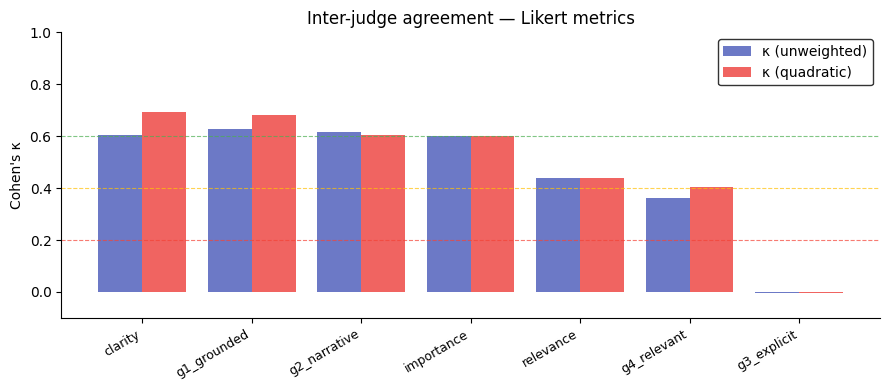

In [14]:
# ── Cell 4: Cohen's κ on Likert (1–3) — quadratic weights for ordinal ─────────
rows = []
for col in LIKERT_COLS:
    a = merged[f"{col}_opus"].astype(int).values
    b = merged[f"{col}_ds"].astype(int).values
    rows.append({
        "metric":           col,
        "kappa":            cohen_kappa_score(a, b),
        "kappa_quadratic":  cohen_kappa_score(a, b, weights="quadratic"),
        "opus_mean":        a.mean(),
        "ds_mean":          b.mean(),
    })
lkdf = pd.DataFrame(rows).sort_values("kappa_quadratic", ascending=False)
print("Cohen's κ — Likert metrics (1–3), with quadratic weights:")
print(lkdf.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(lkdf))
w = 0.4
ax.bar(x - w/2, lkdf["kappa"],           width=w, label="κ (unweighted)", color="#5C6BC0", alpha=0.9)
ax.bar(x + w/2, lkdf["kappa_quadratic"], width=w, label="κ (quadratic)",  color="#EF5350", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(lkdf["metric"], rotation=30, ha="right", fontsize=9)
ax.axhline(0.6, ls="--", color="#4CAF50", linewidth=0.8, alpha=0.7)
ax.axhline(0.4, ls="--", color="#FFC107", linewidth=0.8, alpha=0.7)
ax.axhline(0.2, ls="--", color="#F44336", linewidth=0.8, alpha=0.7)
ax.set_ylim(-0.1, 1.0)
ax.set_ylabel("Cohen's κ")
ax.set_title("Inter-judge agreement — Likert metrics")
ax.legend(frameon=True, edgecolor="black", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_kappa_likert.pdf", bbox_inches="tight")
plt.show()


Binary agreement (Opus vs DeepSeek-v4-pro) — kappa, AC1, % agreement:
    criterion kind  kappa   ac1  pct_agree  opus_rate  ds_rate
        dsm_g  DSM -0.008 0.981      0.982      0.988    0.994
        dsm_e  DSM  0.600 0.967      0.970      0.955    0.967
        dsm_b  DSM  0.758 0.949      0.958      0.906    0.900
  ec_triggers  E&C  0.555 0.926      0.936      0.939    0.906
        dsm_d  DSM  0.507 0.923      0.933      0.912    0.942
        dsm_c  DSM  0.592 0.888      0.912      0.885    0.870
        dsm_a  DSM  0.237 0.869      0.888      0.970    0.876
ec_appraisals  E&C  0.623 0.729      0.842      0.694    0.712
ec_strategies  E&C  0.306 0.676      0.779      0.785    0.818
    ec_threat  E&C  0.358 0.603      0.752      0.833    0.670
    ec_memory  E&C  0.548 0.600      0.788      0.642    0.606


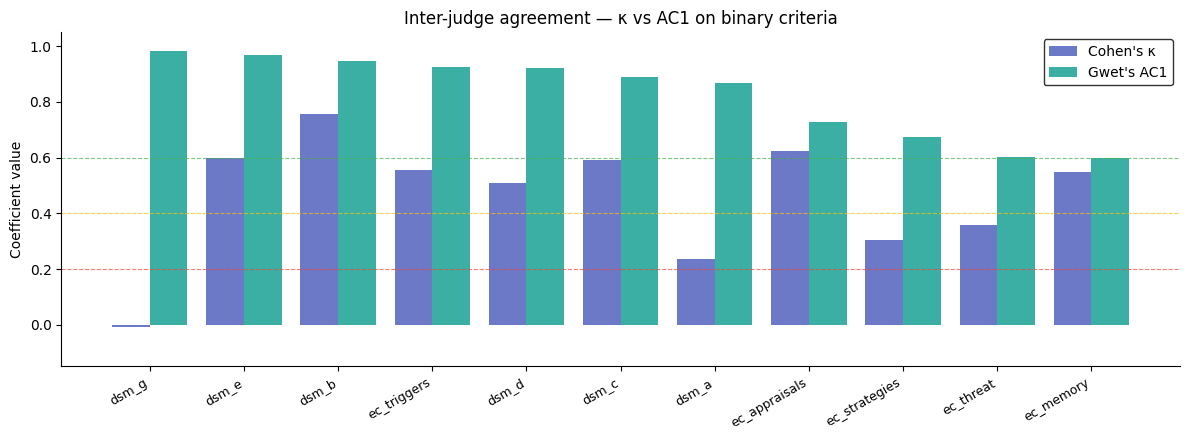

In [24]:
# ── Cell 5: Gwet's AC1 + % agreement on binary criteria (compare with kappa) ─
# AC1 fixes the prevalence paradox that hits low-variance criteria like dsm_g
from irrCAC.raw import CAC

rows = []
for col in BINARY_COLS:
    a = merged[f"{col}_opus"].astype(int).values
    b = merged[f"{col}_ds"].astype(int).values
    pair = pd.DataFrame({"opus": a, "ds": b})
    cac  = CAC(pair, categories=[0, 1])
    ac1  = cac.gwet()["est"]["coefficient_value"]
    rows.append({
        "criterion":  col,
        "kind":       "DSM" if col in DSM_COLS else "E&C",
        "kappa":      cohen_kappa_score(a, b),
        "ac1":        ac1,
        "pct_agree":  (a == b).mean(),
        "opus_rate":  a.mean(),
        "ds_rate":    b.mean(),
    })
kdf2 = pd.DataFrame(rows).sort_values("ac1", ascending=False)
print("Binary agreement (Opus vs DeepSeek-v4-pro) — kappa, AC1, % agreement:")
print(kdf2.round(3).to_string(index=False))

# Side-by-side bar: kappa vs AC1
import matplotlib.pyplot as plt
order = kdf2["criterion"].tolist()
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(order))
w = 0.4
ax.bar(x - w/2, kdf2["kappa"], width=w, label="Cohen's κ",  color="#5C6BC0", alpha=0.9)
ax.bar(x + w/2, kdf2["ac1"],   width=w, label="Gwet's AC1", color="#26A69A", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right", fontsize=9)
ax.axhline(0.6, ls="--", color="#4CAF50", linewidth=0.8, alpha=0.7)
ax.axhline(0.4, ls="--", color="#FFC107", linewidth=0.8, alpha=0.7)
ax.axhline(0.2, ls="--", color="#F44336", linewidth=0.8, alpha=0.7)
ax.set_ylim(-0.15, 1.05)
ax.set_ylabel("Coefficient value")
ax.set_title("Inter-judge agreement — κ vs AC1 on binary criteria")
ax.legend(frameon=True, edgecolor="black", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_kappa_vs_ac1_binary.pdf", bbox_inches="tight")
plt.show()


Likert agreement (Opus vs DeepSeek-v4-pro) — weighted κ, AC2, % agreement:
      metric  kappa_quadratic  ac2_quadratic  pct_agree  opus_mean  ds_mean
 g3_explicit           -0.003          0.998      0.994      2.997    2.997
   relevance            0.437          0.980      0.930      2.903    2.967
     clarity            0.692          0.971      0.918      2.836    2.903
  importance            0.600          0.958      0.882      2.827    2.812
g2_narrative            0.606          0.952      0.879      2.797    2.806
 g1_grounded            0.680          0.950      0.870      2.730    2.806
 g4_relevant            0.403          0.905      0.773      2.773    2.752


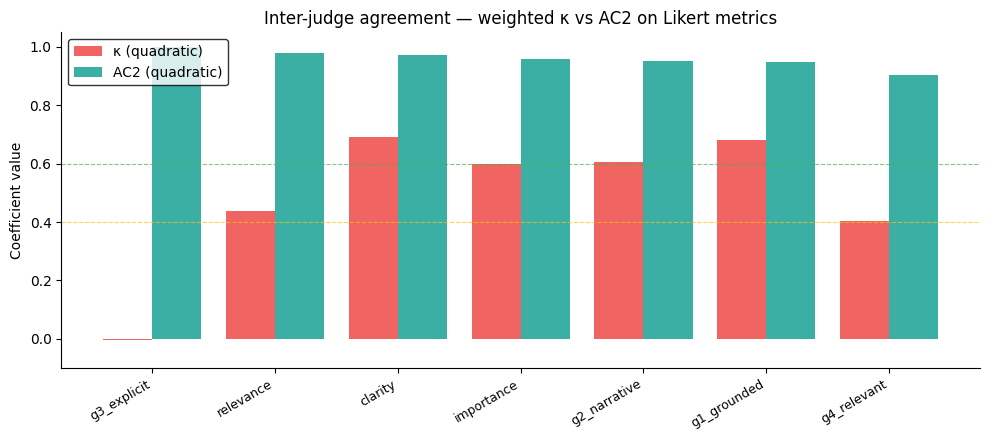

In [25]:
# ── Cell 6: Gwet's AC2 + % agreement on Likert (compare with weighted kappa) ─
# AC2 with quadratic weights is the ordinal analogue of AC1
rows = []
for col in LIKERT_COLS:
    a = merged[f"{col}_opus"].astype(int).values
    b = merged[f"{col}_ds"].astype(int).values
    pair = pd.DataFrame({"opus": a, "ds": b})
    cac  = CAC(pair, weights="quadratic", categories=[1, 2, 3])
    ac2  = cac.gwet()["est"]["coefficient_value"]
    rows.append({
        "metric":           col,
        "kappa_quadratic":  cohen_kappa_score(a, b, weights="quadratic"),
        "ac2_quadratic":    ac2,
        "pct_agree":        (a == b).mean(),
        "opus_mean":        a.mean(),
        "ds_mean":          b.mean(),
    })
lkdf2 = pd.DataFrame(rows).sort_values("ac2_quadratic", ascending=False)
print("Likert agreement (Opus vs DeepSeek-v4-pro) — weighted κ, AC2, % agreement:")
print(lkdf2.round(3).to_string(index=False))

order = lkdf2["metric"].tolist()
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(order))
w = 0.4
ax.bar(x - w/2, lkdf2["kappa_quadratic"], width=w, label="κ (quadratic)", color="#EF5350", alpha=0.9)
ax.bar(x + w/2, lkdf2["ac2_quadratic"],   width=w, label="AC2 (quadratic)", color="#26A69A", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right", fontsize=9)
ax.axhline(0.6, ls="--", color="#4CAF50", linewidth=0.8, alpha=0.7)
ax.axhline(0.4, ls="--", color="#FFC107", linewidth=0.8, alpha=0.7)
ax.set_ylim(-0.1, 1.05)
ax.set_ylabel("Coefficient value")
ax.set_title("Inter-judge agreement — weighted κ vs AC2 on Likert metrics")
ax.legend(frameon=True, edgecolor="black", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "judge_kappa_vs_ac2_likert.pdf", bbox_inches="tight")
plt.show()


In [26]:
# ── Cell 7: κ + AC1 per binary criterion × condition ────────────────────────
CONDS = ["full", "no_formulation", "zero_shot"]
COND_LABELS = {"full": "Full", "no_formulation": "No form.", "zero_shot": "Zero-shot"}

kappa_grid = {}
ac1_grid   = {}

for cond in CONDS:
    sub = merged[merged["condition"] == cond]
    n   = len(sub)
    kappa_grid[cond] = {}
    ac1_grid[cond]   = {}
    for col in BINARY_COLS:
        a = sub[f"{col}_opus"].astype(int).values
        b = sub[f"{col}_ds"].astype(int).values
        # κ guarded against degenerate single-class case
        try:
            kappa_grid[cond][col] = cohen_kappa_score(a, b)
        except Exception:
            kappa_grid[cond][col] = float("nan")
        pair = pd.DataFrame({"opus": a, "ds": b})
        try:
            cac = CAC(pair, categories=[0, 1])
            ac1_grid[cond][col] = cac.gwet()["est"]["coefficient_value"]
        except Exception:
            ac1_grid[cond][col] = float("nan")
    print(f"  {cond}: n={n}")

kappa_tbl = pd.DataFrame(kappa_grid).reindex(BINARY_COLS)
ac1_tbl   = pd.DataFrame(ac1_grid).reindex(BINARY_COLS)
kappa_tbl.columns = [COND_LABELS[c] for c in kappa_tbl.columns]
ac1_tbl.columns   = [COND_LABELS[c] for c in ac1_tbl.columns]

print("\nCohen's κ — binary criteria × condition:")
print(kappa_tbl.round(3).to_string())
print("\nGwet's AC1 — binary criteria × condition:")
print(ac1_tbl.round(3).to_string())

kappa_tbl.round(3).to_csv(ANALYSIS_DIR / "judge_kappa_binary_by_condition.csv")
ac1_tbl.round(3).to_csv(ANALYSIS_DIR / "judge_ac1_binary_by_condition.csv")
print(f"\nSaved: judge_kappa_binary_by_condition.csv | judge_ac1_binary_by_condition.csv")


  full: n=110
  no_formulation: n=110
  zero_shot: n=110

Cohen's κ — binary criteria × condition:
                Full  No form.  Zero-shot
dsm_a          0.277     0.235     -0.015
dsm_b          0.801     0.812     -0.014
dsm_c          0.789     0.467      0.527
dsm_d          0.000    -0.022      0.598
dsm_e          0.584     0.642      0.000
dsm_g         -0.009     0.000      0.000
ec_threat      0.142     0.257      0.504
ec_appraisals  0.469     0.491      0.591
ec_memory      0.600     0.486      0.488
ec_strategies  0.543     0.253      0.151
ec_triggers    0.554     0.305      0.698

Gwet's AC1 — binary criteria × condition:
                Full  No form.  Zero-shot
dsm_a          0.908     0.719      0.952
dsm_b          0.941     0.940      0.962
dsm_c          0.942     0.817      0.901
dsm_d          0.962     0.952      0.833
dsm_e          0.960     0.948      0.991
dsm_g          0.981     0.991      0.972
ec_threat      0.729     0.495      0.583
ec_appraisals  0.8

In [27]:
# ── Cell 8: weighted κ + AC2 (quadratic) per Likert metric × condition ─────
CONDS = ["full", "no_formulation", "zero_shot"]
COND_LABELS = {"full": "Full", "no_formulation": "No form.", "zero_shot": "Zero-shot"}

kappa_q_grid = {}
ac2_grid     = {}

for cond in CONDS:
    sub = merged[merged["condition"] == cond]
    n   = len(sub)
    kappa_q_grid[cond] = {}
    ac2_grid[cond]     = {}
    for col in LIKERT_COLS:
        a = sub[f"{col}_opus"].astype(int).values
        b = sub[f"{col}_ds"].astype(int).values
        try:
            kappa_q_grid[cond][col] = cohen_kappa_score(a, b, weights="quadratic")
        except Exception:
            kappa_q_grid[cond][col] = float("nan")
        pair = pd.DataFrame({"opus": a, "ds": b})
        try:
            cac = CAC(pair, weights="quadratic", categories=[1, 2, 3])
            ac2_grid[cond][col] = cac.gwet()["est"]["coefficient_value"]
        except Exception:
            ac2_grid[cond][col] = float("nan")
    print(f"  {cond}: n={n}")

kq_tbl  = pd.DataFrame(kappa_q_grid).reindex(LIKERT_COLS)
ac2_tbl = pd.DataFrame(ac2_grid).reindex(LIKERT_COLS)
kq_tbl.columns  = [COND_LABELS[c] for c in kq_tbl.columns]
ac2_tbl.columns = [COND_LABELS[c] for c in ac2_tbl.columns]

print("\nWeighted Cohen's κ (quadratic) — Likert × condition:")
print(kq_tbl.round(3).to_string())
print("\nGwet's AC2 (quadratic) — Likert × condition:")
print(ac2_tbl.round(3).to_string())

kq_tbl.round(3).to_csv(ANALYSIS_DIR / "judge_kappa_likert_by_condition.csv")
ac2_tbl.round(3).to_csv(ANALYSIS_DIR / "judge_ac2_likert_by_condition.csv")
print(f"\nSaved: judge_kappa_likert_by_condition.csv | judge_ac2_likert_by_condition.csv")


  full: n=110
  no_formulation: n=110
  zero_shot: n=110

Weighted Cohen's κ (quadratic) — Likert × condition:
               Full  No form.  Zero-shot
clarity       0.832     0.214      0.209
relevance     0.571    -0.016      0.438
importance    0.656     0.596      0.545
g1_grounded   0.736     0.549      0.669
g2_narrative  0.654     0.439      0.601
g3_explicit   0.000       NaN      0.000
g4_relevant   0.479     0.216      0.438

Gwet's AC2 (quadratic) — Likert × condition:
               Full  No form.  Zero-shot
clarity       0.959     0.969      0.983
relevance     0.975     0.983      0.982
importance    0.969     0.974      0.925
g1_grounded   0.934     0.960      0.954
g2_narrative  0.977     0.960      0.911
g3_explicit   0.998     1.000      0.998
g4_relevant   0.890     0.914      0.911

Saved: judge_kappa_likert_by_condition.csv | judge_ac2_likert_by_condition.csv


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)


## 13b. Validity of the scaling judge (n = 330, +DeepSeek-v4-flash)
We now add **DeepSeek-v4-flash** as a third judge on the *same* 330 vignettes (extracted from v12/v13/v14 by joining on `model × condition × persona_id`).  
Question: does the cost-efficient judge track the two leading anchor judges?  

Reported per criterion: pairwise κ / AC1 (or weighted κ / AC2) and three-way Fleiss κ + Gwet AC.

In [28]:
# ── Cell 13b-1: Load v4-flash on the 330 set and build a 3-judge merge ──────
import json
import pandas as pd
from pathlib import Path

V10        = Path("../data/llm_judge_v10")
COND_TO_VER = {"full": "v12", "no_formulation": "v13", "zero_shot": "v14"}
DATA_DIR   = Path("../data")

# Build (model, condition, persona_id) -> flash row lookup from v12/v13/v14
flash_lookup = {}
for cond, ver in COND_TO_VER.items():
    base = DATA_DIR / f"llm_judge_{ver}"
    for model_dir in base.iterdir():
        fp = model_dir / "llm_judge_deepseek-v4-flash.jsonl"
        if not fp.exists():
            continue
        with open(fp, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                key = (r["model"], r["condition"], int(r["persona_id"]))
                flash_lookup[key] = r

# Already have `merged` = Opus ⨝ v4-pro on vignette_id with _opus / _ds suffixes.
# Add v4-flash columns by joining on (model, condition, persona_id).
opus = pd.read_csv(V10 / "llm_judge_claude-opus-4-5.csv")
dspro = pd.read_csv(V10 / "llm_judge_deepseek-v4-pro.csv")
merged3 = opus.merge(dspro, on="vignette_id", suffixes=("_opus", "_dspro"))

ALL_METRIC_COLS = LIKERT_COLS + BINARY_COLS

def flash_value(row, col):
    key = (row["model_opus"], row["condition_opus"], int(row["persona_id_opus"]))
    r = flash_lookup.get(key)
    return r[col] if r is not None else None

for col in ALL_METRIC_COLS:
    merged3[f"{col}_flash"] = merged3.apply(lambda r, c=col: flash_value(r, c), axis=1)

merged3["model"]     = merged3["model_opus"]
merged3["condition"] = merged3["condition_opus"]

# Confirm full coverage
missing = merged3[[f"{c}_flash" for c in ALL_METRIC_COLS]].isna().sum().sum()
print(f"3-judge merge complete: {len(merged3)} vignettes  |  missing flash cells: {missing}")


3-judge merge complete: 330 vignettes  |  missing flash cells: 0


In [29]:
# ── Cell 13b-2: Binary criteria — pairwise + three-way agreement ────────────
from sklearn.metrics import cohen_kappa_score
from irrCAC.raw import CAC

def safe_kappa(a, b, weights=None):
    try: return cohen_kappa_score(a, b, weights=weights)
    except Exception: return float("nan")

def safe_gwet(df, categories, weights=None):
    try:
        cac = CAC(df, categories=categories, weights=weights) if weights else \
              CAC(df, categories=categories)
        return cac.gwet()["est"]["coefficient_value"]
    except Exception: return float("nan")

def safe_fleiss(df, categories, weights=None):
    try:
        cac = CAC(df, categories=categories, weights=weights) if weights else \
              CAC(df, categories=categories)
        return cac.fleiss()["est"]["coefficient_value"]
    except Exception: return float("nan")

rows = []
for col in BINARY_COLS:
    o = merged3[f"{col}_opus"].astype(int).values
    p = merged3[f"{col}_dspro"].astype(int).values
    f = merged3[f"{col}_flash"].astype(int).values

    triple = pd.DataFrame({"opus": o, "dspro": p, "flash": f})
    pair_OP = triple[["opus", "dspro"]]
    pair_FO = triple[["flash", "opus"]]
    pair_FP = triple[["flash", "dspro"]]

    rows.append({
        "criterion": col,
        "kind":       "DSM" if col in DSM_COLS else "E&C",
        "k_OvP":      safe_kappa(o, p),
        "k_FvO":      safe_kappa(f, o),
        "k_FvP":      safe_kappa(f, p),
        "Fleiss_3":   safe_fleiss(triple, categories=[0, 1]),
        "AC1_OvP":    safe_gwet(pair_OP, categories=[0, 1]),
        "AC1_FvO":    safe_gwet(pair_FO, categories=[0, 1]),
        "AC1_FvP":    safe_gwet(pair_FP, categories=[0, 1]),
        "AC1_3":      safe_gwet(triple,  categories=[0, 1]),
    })

bin_df = pd.DataFrame(rows).set_index("criterion")
print("Binary criteria — pairwise + 3-judge agreement (O=Opus, P=DSpro, F=Flash):")
print(bin_df.round(3).to_string())
bin_df.round(3).to_csv(ANALYSIS_DIR / "judge3_binary_agreement.csv")
print(f"\nSaved -> {ANALYSIS_DIR / 'judge3_binary_agreement.csv'}")


Binary criteria — pairwise + 3-judge agreement (O=Opus, P=DSpro, F=Flash):
              kind  k_OvP  k_FvO  k_FvP  Fleiss_3  AC1_OvP  AC1_FvO  AC1_FvP  AC1_3
criterion                                                                          
dsm_a          DSM  0.237  0.285  0.474     0.344    0.869    0.896    0.867  0.878
dsm_b          DSM  0.758  0.827  0.731     0.771    0.949    0.963    0.941  0.951
dsm_c          DSM  0.592  0.551  0.567     0.570    0.888    0.909    0.904  0.900
dsm_d          DSM  0.507  0.430  0.456     0.464    0.923    0.913    0.936  0.924
dsm_e          DSM  0.600  0.680  0.624     0.635    0.967    0.974    0.974  0.972
dsm_g          DSM -0.008  0.567 -0.007     0.215    0.981    0.991    0.985  0.986
ec_threat      E&C  0.358  0.403  0.470     0.405    0.603    0.668    0.602  0.624
ec_appraisals  E&C  0.623  0.673  0.592     0.629    0.729    0.766    0.718  0.738
ec_memory      E&C  0.548  0.636  0.579     0.587    0.600    0.682    0.619  0.634
e

In [30]:
# ── Cell 13b-3: Likert metrics — pairwise + three-way agreement ─────────────
rows = []
for col in LIKERT_COLS:
    o = merged3[f"{col}_opus"].astype(int).values
    p = merged3[f"{col}_dspro"].astype(int).values
    f = merged3[f"{col}_flash"].astype(int).values

    triple = pd.DataFrame({"opus": o, "dspro": p, "flash": f})
    pair_OP = triple[["opus", "dspro"]]
    pair_FO = triple[["flash", "opus"]]
    pair_FP = triple[["flash", "dspro"]]

    rows.append({
        "metric":      col,
        "wk_OvP":      safe_kappa(o, p, weights="quadratic"),
        "wk_FvO":      safe_kappa(f, o, weights="quadratic"),
        "wk_FvP":      safe_kappa(f, p, weights="quadratic"),
        "Fleiss_q3":   safe_fleiss(triple, categories=[1, 2, 3], weights="quadratic"),
        "AC2_OvP":     safe_gwet(pair_OP, categories=[1, 2, 3], weights="quadratic"),
        "AC2_FvO":     safe_gwet(pair_FO, categories=[1, 2, 3], weights="quadratic"),
        "AC2_FvP":     safe_gwet(pair_FP, categories=[1, 2, 3], weights="quadratic"),
        "AC2_3":       safe_gwet(triple,  categories=[1, 2, 3], weights="quadratic"),
    })

lik_df = pd.DataFrame(rows).set_index("metric")
print("Likert metrics — pairwise + 3-judge agreement (quadratic weights):")
print(lik_df.round(3).to_string())
lik_df.round(3).to_csv(ANALYSIS_DIR / "judge3_likert_agreement.csv")
print(f"\nSaved -> {ANALYSIS_DIR / 'judge3_likert_agreement.csv'}")


Likert metrics — pairwise + 3-judge agreement (quadratic weights):
              wk_OvP  wk_FvO  wk_FvP  Fleiss_q3  AC2_OvP  AC2_FvO  AC2_FvP  AC2_3
metric                                                                           
clarity        0.692   0.618   0.727      0.674    0.971    0.967    0.983  0.974
relevance      0.437   0.549   0.317      0.446    0.980    0.977    0.978  0.978
importance     0.600   0.474   0.473      0.500    0.958    0.914    0.912  0.929
g1_grounded    0.680   0.803   0.719      0.736    0.950    0.964    0.958  0.957
g2_narrative   0.606   0.560   0.478      0.537    0.952    0.923    0.908  0.929
g3_explicit   -0.003   0.000   0.000     -0.002    0.998    0.999    0.999  0.999
g4_relevant    0.403   0.507   0.392      0.433    0.905    0.928    0.911  0.915

Saved -> ..\data\analysis\judge3_likert_agreement.csv


## 14. DeepSeek-v4-flash judge across all 3 conditions (n = 5500 per condition)
Judge: `deepseek-v4-flash` · 11 models × 500 personas per condition  
- **v12** → Full formulation · `data/llm_judge_v12/`  
- **v13** → No formulation · `data/llm_judge_v13/`  
- **v14** → Zero-shot · `data/llm_judge_v14/`

In [15]:
# ── Cell A: Load all three condition runs (v12=full, v13=no_formulation, v14=zero_shot)
import json
import pandas as pd
from pathlib import Path

ANALYSIS_DIR = Path("../data/analysis")
DATA_DIR     = Path("../data")
JUDGE_FILE   = "llm_judge_deepseek-v4-flash.jsonl"

CONDITION_DIRS = {
    "full":           DATA_DIR / "llm_judge_v12",
    "no_formulation": DATA_DIR / "llm_judge_v13",
    "zero_shot":      DATA_DIR / "llm_judge_v14",
}

rows = []
for cond, base in CONDITION_DIRS.items():
    for model_dir in sorted(base.iterdir()):
        if not model_dir.is_dir():
            continue
        fp = model_dir / JUDGE_FILE
        if not fp.exists():
            continue
        with open(fp, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                r = json.loads(line)
                r["_condition"] = cond
                rows.append(r)

flash_df = pd.DataFrame(rows)
print(f"Loaded {len(flash_df)} ratings")
print(flash_df.groupby(["_condition", "model"]).size().unstack(fill_value=0).to_string())


Loaded 16500 ratings
model           claude-haiku-4-5  claude-sonnet-4-6  deepseek-chat  deepseek-reasoner  gemini-2.5-flash  gemini-2.5-pro  gpt-4o-mini  gpt-5.4  gpt-5.4-mini  qwen2.5-32b  qwen3.6-35b
_condition                                                                                                                                                                           
full                         500                500            500                500               500             500          500      500           500          500          500
no_formulation               500                500            500                500               500             500          500      500           500          500          500
zero_shot                    500                500            500                500               500             500          500      500           500          500          500


In [17]:
# ── Cell B: Mean per metric × condition (table) ──────────────────────────────
LIKERT_COLS = ["clarity", "relevance", "importance",
               "g1_grounded", "g2_narrative", "g3_explicit", "g4_relevant"]
DSM_COLS    = ["dsm_a", "dsm_b", "dsm_c", "dsm_d", "dsm_e", "dsm_g"]
EC_COLS     = ["ec_threat", "ec_appraisals", "ec_memory", "ec_strategies", "ec_triggers"]
ALL_METRICS = LIKERT_COLS + DSM_COLS + EC_COLS

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}

# Readable row labels (raw col → human name)
METRIC_LABELS = {
    "clarity":       "Clarity",
    "relevance":     "Relevance",
    "importance":    "Importance",
    "g1_grounded":   "G1 — Grounded",
    "g2_narrative":  "G2 — Narrative",
    "g3_explicit":   "G3 — Explicit",
    "g4_relevant":   "G4 — Relevant",
    "dsm_a":         "DSM A — Trauma exposure",
    "dsm_b":         "DSM B — Intrusion",
    "dsm_c":         "DSM C — Avoidance",
    "dsm_d":         "DSM D — Neg. cognitions",
    "dsm_e":         "DSM E — Hyperarousal",
    "dsm_g":         "DSM G — Impairment",
    "ec_threat":     "E&C — Threat",
    "ec_appraisals": "E&C — Appraisals",
    "ec_memory":     "E&C — Memory",
    "ec_strategies": "E&C — Strategies",
    "ec_triggers":   "E&C — Triggers",
}

tbl = flash_df.groupby("_condition")[ALL_METRICS].mean().T
tbl = tbl[[c for c in CONDITION_LABELS if c in tbl.columns]]
tbl.columns = [CONDITION_LABELS[c] for c in tbl.columns]
tbl.index = [METRIC_LABELS[m] for m in tbl.index]
tbl.index.name = "metric"

print("Mean score per metric × condition (DeepSeek-v4-flash judge):")
print(tbl.round(3).to_string())

tbl.round(3).to_csv(ANALYSIS_DIR / "judge_flash_means_by_condition.csv")
print(f"\nSaved -> {ANALYSIS_DIR / 'judge_flash_means_by_condition.csv'}")


Mean score per metric × condition (DeepSeek-v4-flash judge):
                         Full formulation  No formulation  Zero-shot
metric                                                              
Clarity                             2.861           2.991      2.988
Relevance                           2.908           2.950      2.919
Importance                          2.748           2.653      2.487
G1 — Grounded                       2.707           2.781      2.735
G2 — Narrative                      2.837           2.759      2.432
G3 — Explicit                       2.993           2.995      2.995
G4 — Relevant                       2.821           2.869      2.775
DSM A — Trauma exposure             0.877           0.845      0.891
DSM B — Intrusion                   0.913           0.925      0.973
DSM C — Avoidance                   0.904           0.925      0.894
DSM D — Neg. cognitions             0.899           0.919      0.868
DSM E — Hyperarousal                0.920 

In [31]:
# ── Cell: Paired t-tests per metric × condition pair (Bonferroni-corrected) ─
# Uses the same flash_df built by the earlier "Cell A: Load all three condition runs" cell.
# Pairs each (model, persona) across the three conditions; binary criteria treated as 0/1 proportions.
from scipy.stats import ttest_rel

LIKERT_COLS = ["clarity", "relevance", "importance",
               "g1_grounded", "g2_narrative", "g3_explicit", "g4_relevant"]
DSM_COLS    = ["dsm_a", "dsm_b", "dsm_c", "dsm_d", "dsm_e", "dsm_g"]
EC_COLS     = ["ec_threat", "ec_appraisals", "ec_memory", "ec_strategies", "ec_triggers"]
ALL_METRICS = LIKERT_COLS + DSM_COLS + EC_COLS

CONDS = ["full", "no_formulation", "zero_shot"]
PAIRS = [("full", "no_formulation"), ("full", "zero_shot"), ("no_formulation", "zero_shot")]
PAIR_LABELS = {("full", "no_formulation"): "F vs N",
               ("full", "zero_shot"):      "F vs Z",
               ("no_formulation", "zero_shot"): "N vs Z"}

def sig(p):
    if pd.isna(p): return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "** "
    if p < 0.05:  return "*  "
    return "ns "

# Ensure persona_id is int so the pivot key is clean
flash_df["_pid"] = flash_df["persona_id"].astype(int)

rows = []
for col in ALL_METRICS:
    pivot = flash_df.pivot_table(
        index=["model", "_pid"], columns="_condition", values=col, aggfunc="first"
    )
    pivot = pivot.dropna(subset=CONDS).astype(float)
    n = len(pivot)
    row = {"metric": col, "n": n}
    for c1, c2 in PAIRS:
        _, p = ttest_rel(pivot[c1].values, pivot[c2].values)
        p_adj = min(p * 3, 1.0)
        row[f"d_{PAIR_LABELS[(c1, c2)]}"] = float(pivot[c1].mean() - pivot[c2].mean())
        row[f"p_{PAIR_LABELS[(c1, c2)]}"] = p_adj
        row[f"sig_{PAIR_LABELS[(c1, c2)]}"] = sig(p_adj)
    rows.append(row)

ttest_df = pd.DataFrame(rows).set_index("metric")
print("Paired t-tests (Bonferroni-corrected), n =", ttest_df["n"].iloc[0], "(model, persona) pairs per condition:")
print()
# Compact view: just the significance stars
print(ttest_df[[f"sig_{lbl}" for lbl in PAIR_LABELS.values()]].to_string(
    header=["F vs N", "F vs Z", "N vs Z"]))
print()
# Detailed view: mean differences and p-values
print("Mean differences and adjusted p-values:")
print(ttest_df[[f"d_{lbl}" for lbl in PAIR_LABELS.values()]
              + [f"p_{lbl}" for lbl in PAIR_LABELS.values()]].round(4).to_string(
    header=["dF-N", "dF-Z", "dN-Z", "pF-N", "pF-Z", "pN-Z"]))

ttest_df.round(4).to_csv(ANALYSIS_DIR / "judge_flash_pairwise_ttests.csv")
print(f"\nSaved -> {ANALYSIS_DIR / 'judge_flash_pairwise_ttests.csv'}")


Paired t-tests (Bonferroni-corrected), n = 5500 (model, persona) pairs per condition:

              F vs N F vs Z N vs Z
metric                            
clarity          ***    ***    ns 
relevance        ***    *      ***
importance       ***    ***    ***
g1_grounded      ***    ***    ***
g2_narrative     ***    ***    ***
g3_explicit      ns     ns     ns 
g4_relevant      ***    ***    ***
dsm_a            ***    *      ***
dsm_b            **     ***    ***
dsm_c            ***    ns     ***
dsm_d            ***    ***    ***
dsm_e            ns     ***    ***
dsm_g            ***    ***    ***
ec_threat        ***    ***    ***
ec_appraisals    ns     ***    ***
ec_memory        ns     ***    ***
ec_strategies    ***    ***    ***
ec_triggers      ns     **     ***

Mean differences and adjusted p-values:
                 dF-N    dF-Z    dN-Z    pF-N    pF-Z    pN-Z
metric                                                       
clarity       -0.1302 -0.1271  0.0031  0.0000  0

In [18]:
# ── Cell C: Per-(model × condition) heatmap helper ───────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]
_COND_ORDER = ["full", "no_formulation", "zero_shot"]
_COND_LABELS_SHORT = {"full": "Full", "no_formulation": "No form.", "zero_shot": "Zero-shot"}

def per_model_heatmap_grid(cols, label_map, title, fname, cmap, vmin, vmax, fmt):
    """Row of small heatmaps, one per metric — models (rows) × conditions (cols)."""
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(n * 3.6, 5.5), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        pivot = (
            flash_df.groupby(["model", "_condition"])[col].mean()
            .unstack("_condition")
        )
        pivot = pivot[[c for c in _COND_ORDER if c in pivot.columns]]
        pivot.columns = [_COND_LABELS_SHORT[c] for c in pivot.columns]
        pivot = pivot.reindex(_EVAL_MODELS)
        sns.heatmap(
            pivot, ax=ax, annot=True, fmt=fmt, cmap=cmap,
            vmin=vmin, vmax=vmax, linewidths=0.4,
            cbar=(ax == axes[-1]),
            cbar_kws={"shrink": 0.8},
        )
        ax.set_title(label_map[col], fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Model" if ax == axes[0] else "")
        ax.tick_params(axis="x", rotation=20, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / fname, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {ANALYSIS_DIR / fname}")

print("Helper ready: per_model_heatmap_grid(...)")


Helper ready: per_model_heatmap_grid(...)


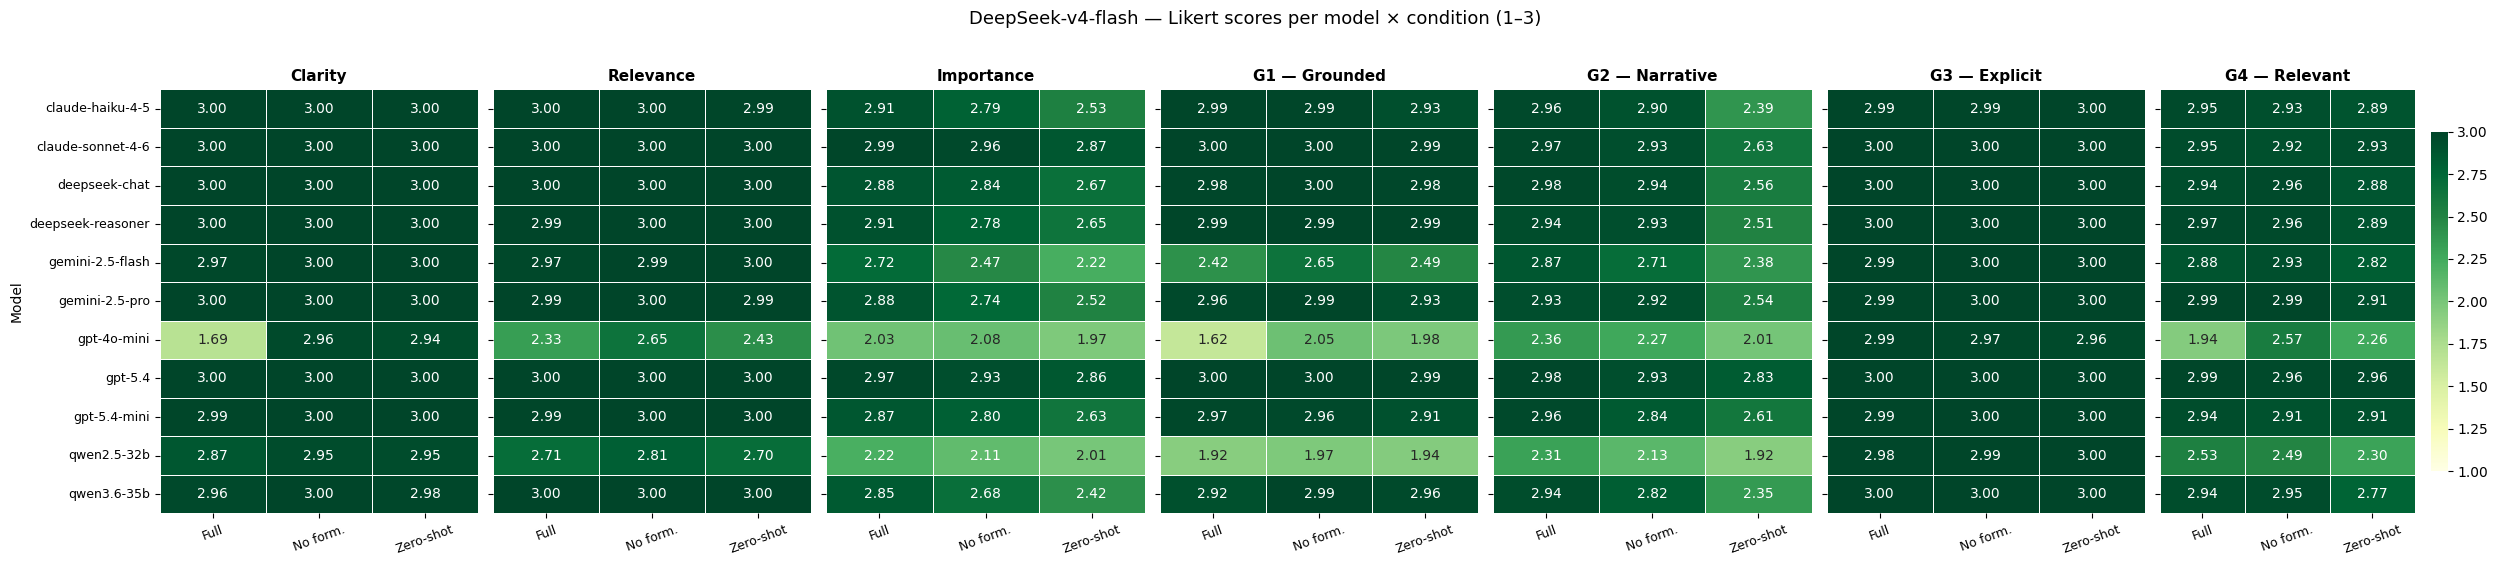

Saved -> ..\data\analysis\judge_flash_likert_per_model.pdf


In [19]:
# ── Cell D: Likert metrics — clarity / relevance / importance / g1–g4 ───────
LIKERT_LABELS = {
    "clarity":      "Clarity",
    "relevance":    "Relevance",
    "importance":   "Importance",
    "g1_grounded":  "G1 — Grounded",
    "g2_narrative": "G2 — Narrative",
    "g3_explicit":  "G3 — Explicit",
    "g4_relevant":  "G4 — Relevant",
}

per_model_heatmap_grid(
    LIKERT_COLS, LIKERT_LABELS,
    "DeepSeek-v4-flash — Likert scores per model × condition (1–3)",
    "judge_flash_likert_per_model.pdf",
    cmap="YlGn", vmin=1, vmax=3, fmt=".2f",
)


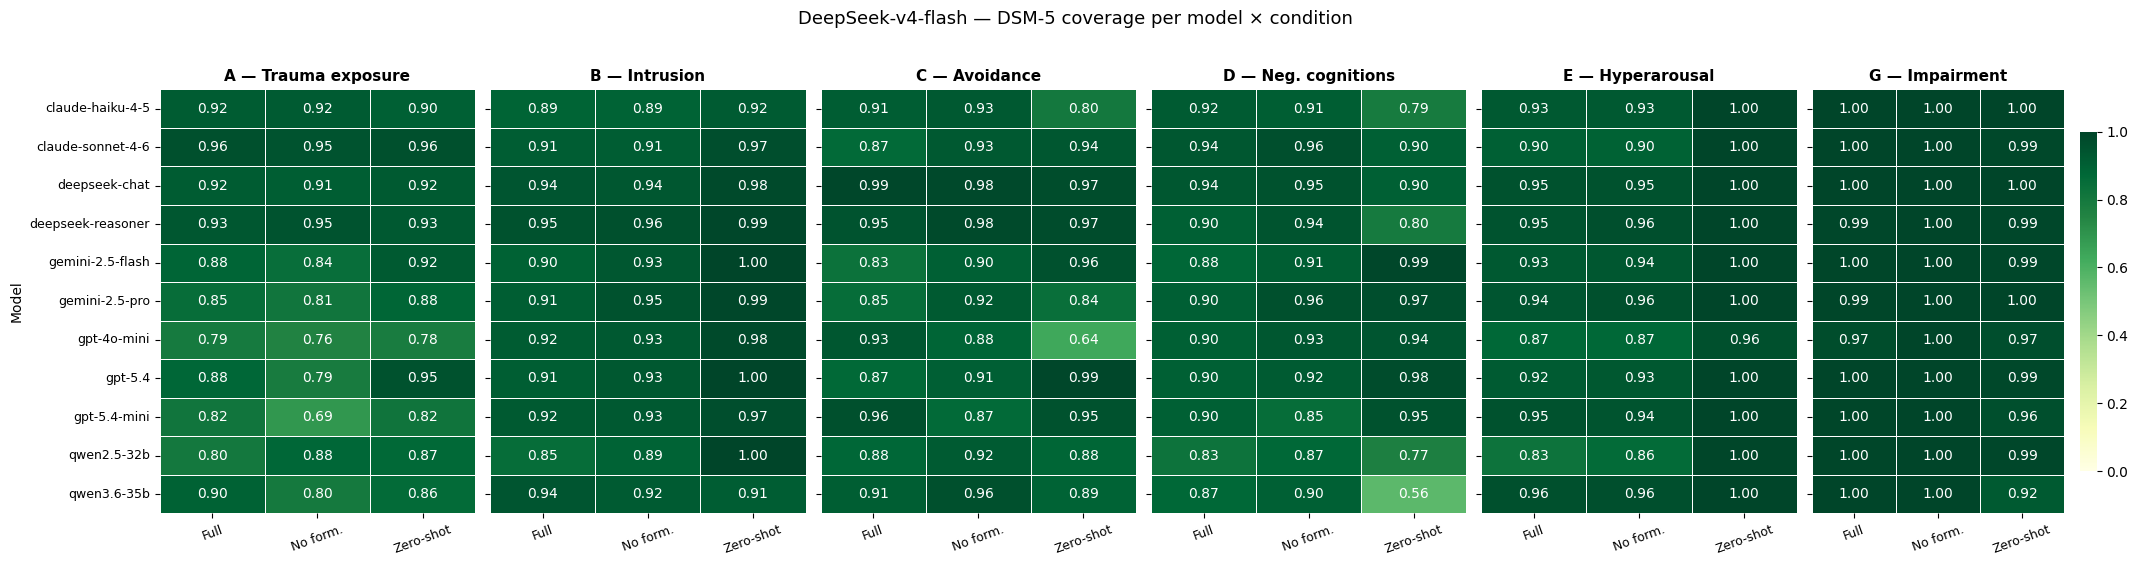

Saved -> ..\data\analysis\judge_flash_dsm_per_model.pdf


In [21]:
# ── Cell E: DSM-5 criteria — per model × condition ──────────────────────────
DSM_LABELS = {
    "dsm_a": "A — Trauma exposure",
    "dsm_b": "B — Intrusion",
    "dsm_c": "C — Avoidance",
    "dsm_d": "D — Neg. cognitions",
    "dsm_e": "E — Hyperarousal",
    "dsm_g": "G — Impairment",
}

per_model_heatmap_grid(
    DSM_COLS, DSM_LABELS,
    "DeepSeek-v4-flash — DSM-5 coverage per model × condition",
    "judge_flash_dsm_per_model.pdf",
    cmap="YlGn", vmin=0, vmax=1, fmt=".2f",
)


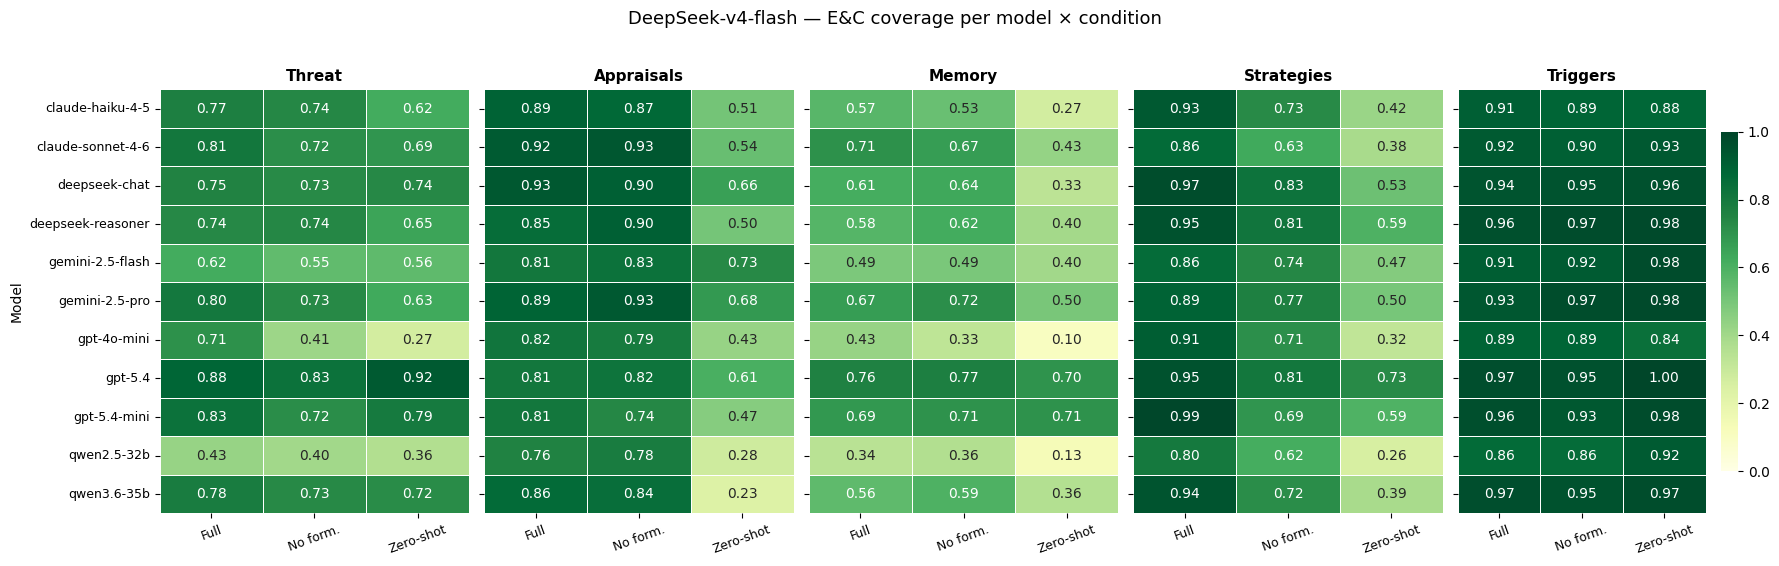

Saved -> ..\data\analysis\judge_flash_ec_per_model.pdf


In [23]:
# ── Cell F: Ehlers & Clark components — per model × condition ───────────────
EC_LABELS = {
    "ec_threat":     "Threat",
    "ec_appraisals": "Appraisals",
    "ec_memory":     "Memory",
    "ec_strategies": "Strategies",
    "ec_triggers":   "Triggers",
}

per_model_heatmap_grid(
    EC_COLS, EC_LABELS,
    "DeepSeek-v4-flash — E&C coverage per model × condition",
    "judge_flash_ec_per_model.pdf",
    cmap="YlGn", vmin=0, vmax=1, fmt=".2f",
)
